# -- **Trabajo Práctico:** Aprendizaje por Refuerzo en FrozenLake

# -- **Alumno:** Gallo, Marcos

# -- **Profesora:** Diedrich, Ana Laura

# -- **Materia:** Aprendizaje automático 2

## Instalar librerias

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import seaborn as sns
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

## Reproducibilidad

**Nota:**

---


 Se prueba agregando esta función que introduce una semilla de reproducibilidad de manera mas abarcativa, porque no lograba generar el mismo resultado cada vez que ejecutaba el entrenamiento y evaluación. Esto no permitía que pudiera comparar de manera precisa como afectaba cada modificación que realizaba en los parámetros de entrenamiento de cada agente.

In [3]:
def set_seed(seed = 12, env=None):
    import random
    import numpy as np
    import torch

    # Semillas básicas
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # si usás CUDA

    # Para entornos deterministas en GPU (PyTorch)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Si se pasa un entorno Gymnasium, fijar sus semillas también
    if env is not None:
        env.reset(seed=seed)
        if hasattr(env, "action_space"):
            env.action_space.seed(seed)
        if hasattr(env, "observation_space"):
            env.observation_space.seed(seed)


In [ ]:
"""np.random.seed(42)
torch.manual_seed(42)
random.seed(42)"""

'np.random.seed(42)\ntorch.manual_seed(42)\nrandom.seed(42)'

## Crear el entorno

In [4]:
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True, render_mode='ansi')
print("🏔️ ENTORNO FROZENLAKE")
print("=" * 50)
print(f"Número de estados: {env.observation_space.n}")
print(f"Número de acciones: {env.action_space.n}")
print(f"Acciones: {['Izquierda', 'Abajo', 'Derecha', 'Arriba']}")

set_seed(env=env)

🏔️ ENTORNO FROZENLAKE
Número de estados: 16
Número de acciones: 4
Acciones: ['Izquierda', 'Abajo', 'Derecha', 'Arriba']


## Mostrar el mapa

In [5]:
print("\n🗺️ MAPA DEL ENTORNO:")
obs, info = env.reset()

print(env.render())
print("\nLeyenda:")
print("S = Start (Inicio)")
print("F = Frozen (Hielo seguro)")
print("H = Hole (Hoyo - termina episodio)")
print("G = Goal (Objetivo - +1 recompensa)")


🗺️ MAPA DEL ENTORNO:

SFFF
FHFH
FFFH
HFFG


Leyenda:
S = Start (Inicio)
F = Frozen (Hielo seguro)
H = Hole (Hoyo - termina episodio)
G = Goal (Objetivo - +1 recompensa)


## Función para convertir estado numérico a posición (fila, columna)

In [6]:

def estado_a_posicion(estado):
  return estado // 4, estado % 4

## Funcion para visualizar politica

In [7]:
def visualizar_politica(policy, title="Política"):     #policy: un array de 16 enteros (uno por cada estado del entorno), donde cada número representa una acción (0 a 3).
  acciones_simbolos = ['←', '↓', '→', '↑']             # Define símbolos para representar las acciones:
  grid = np.array(acciones_simbolos)[policy].reshape(4, 4) # Convierte la política en una cuadrícula 4x4 de símbolos visuales.
  plt.figure(figsize=(6, 6))
  plt.imshow(np.ones((4, 4)), cmap='Blues', alpha=0.3) # Crea una figura y dibuja un fondo azul claro como tablero.

  for i in range(4):                                  # Bucle para agregar texto en cada celda:
      for j in range(4):
          estado = i * 4 + j
          if estado == 0:  # Start
              plt.text(j, i, f'S\n{grid[i,j]}', ha='center', va='center', fontsize=14, fontweight='bold')
          elif estado == 15:  # Goal
              plt.text(j, i, f'G\n{grid[i,j]}', ha='center', va='center', fontsize=14, fontweight='bold')
          elif estado in [5, 7, 11, 12]:  # Holes
              plt.text(j, i, f'H\n{grid[i,j]}', ha='center', va='center', fontsize=14, fontweight='bold', color='red')
          else:
              plt.text(j, i, grid[i,j], ha='center', va='center', fontsize=16)

  plt.xlim(-0.5, 3.5)
  plt.ylim(-0.5, 3.5)
  plt.xticks([])
  plt.yticks([])
  plt.title(title, fontsize=16)
  plt.grid(True, alpha=0.3)
  plt.show()

## Politica aleatoria

In [8]:
class PoliticaAleatoria:
  """Política que selecciona acciones completamente al azar"""
  def __init__(self, n_acciones):
      self.n_acciones = n_acciones  # Guarda cuántas acciones hay (en FrozenLake, 4).
      self.nombre = "Política Aleatoria" # Le da un nombre descriptivo.

  def seleccionar_accion(self, estado):    # Ignora el estado (porque la política no es informada).
      """Selecciona una acción aleatoria"""
      return np.random.randint(self.n_acciones) #Devuelve un número aleatorio entre 0 y n_acciones - 1

  def entrenar(self, env, episodios=1000): # Aunque se llama entrenar, solo ejecuta episodios para medir rendimiento.
      """La política aleatoria no se entrena, solo evaluamos su desempeño"""
      print(f"🎲 Evaluando {self.nombre}...")
      recompensas = []
      exitos = 0

      for episodio in range(episodios):
          estado, _ = env.reset()      # Reinicia el entorno con env.reset()
          recompensa_total = 0
          terminado = False
          pasos = 0

          while not terminado and pasos < 100:   # Corre hasta 100 pasos por episodio (para evitar loops infinitos)
              accion = self.seleccionar_accion(estado)
              estado, recompensa, terminado, truncated, _ = env.step(accion)
              recompensa_total += recompensa # Suma recompensas
              pasos += 1

              if truncated:
                  terminado = True

          if recompensa_total > 0:  # Cuenta cuántos episodios terminan en éxito (recompensa_total > 0)
              exitos += 1
          recompensas.append(recompensa_total)

          if (episodio + 1) % 200 == 0:     # Muestra el progreso cada 200 episodios
              tasa_exito = exitos / (episodio + 1)
              print(f"Episodio {episodio + 1}: Tasa de éxito = {tasa_exito:.3f}")

      tasa_exito_final = exitos / episodios
      print(f"\n📊 Resultados {self.nombre}:")
      print(f"Tasa de éxito final: {tasa_exito_final:.3f}") # Muestra tasa de éxito (éxitos / episodios)
      print(f"Recompensa promedio: {np.mean(recompensas):.3f}") # Calcula recompensa promedio

      return recompensas, tasa_exito_final

## Crear y evaluar política aleatoria

 Crea una instancia de la clase PoliticaAleatoria
Usa `env.action_space.n` para obtener el número de acciones posibles (en FrozenLake-v1, esto es 4: Izquierda, Abajo, Derecha, Arriba).

 Evalúa al agente aleatorio durante 1000 episodios
Retorna dos métricas:

`recompensas_aleatorio`: lista con las recompensas totales por episodio (en FrozenLake, es 0 o 1).

`tasa_exito_aleatorio_1000`

In [9]:
set_seed(env=env)
agente_aleatorio = PoliticaAleatoria(env.action_space.n)
recompensas_aleatorio, tasa_exito_aleatorio_1000 = agente_aleatorio.entrenar(env, episodios=1000)


🎲 Evaluando Política Aleatoria...
Episodio 200: Tasa de éxito = 0.025
Episodio 400: Tasa de éxito = 0.018
Episodio 600: Tasa de éxito = 0.013
Episodio 800: Tasa de éxito = 0.014
Episodio 1000: Tasa de éxito = 0.012

📊 Resultados Política Aleatoria:
Tasa de éxito final: 0.012
Recompensa promedio: 0.012


## Visualizar política aleatoria (todas las acciones tienen la misma probabilidad)

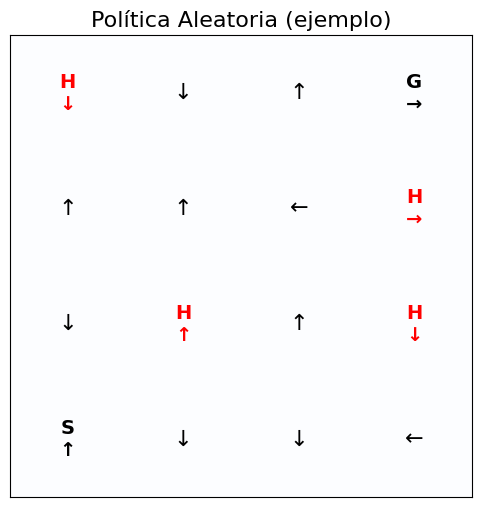

In [10]:

politica_aleatoria = np.random.randint(0, 4, 16)  # Solo para visualización
visualizar_politica(politica_aleatoria, "Política Aleatoria (ejemplo)")

## Politica Q-learning

`def__init__(..):`

Se definen hiperparámetros:

`lr`: tasa de aprendizaje (cuánto se ajustan los valores Q).

`gamma`: factor de descuento para recompensas futuras.

`epsilon`: probabilidad de explorar al elegir una acción.

Se crea una tabla Q de ceros con una fila por cada estado y una columna por cada acción

`def seleccionar_accion(self, estado, entrenando=True):`

Durante el entrenamiento, se elige una acción al azar con probabilidad epsilon.

De lo contrario, se elige la acción con mayor valor Q conocido en el estado actual.

`def actualizar_q(self, estado, accion, recompensa, siguiente_estado, terminado):`

Se calcula el valor objetivo (target) según si el episodio terminó o no.

Se actualiza el valor Q usando la fórmula de Q-Learning:

𝑄
(
𝑠
,
𝑎
)
←
𝑄
(
𝑠
,
𝑎
)
+
𝛼
(
𝑟
+
𝛾
max
⁡
𝑄
(
𝑠
′
,
𝑎
′
)
−
𝑄
(
𝑠
,
𝑎
)
)
Q(s,a)←Q(s,a)+α(r+γmaxQ(s
′
 ,a
′
 )−Q(s,a))

 `def decay_epsilon(self):`

 Se reduce gradualmente epsilon en cada episodio para explorar menos y explotar más a medida que el agente aprende.

` def entrenar(self, env, episodios=10000):`

Se entrena el agente durante episodios repeticiones:

En cada paso, selecciona una acción, ejecuta la acción en el entorno y actualiza la tabla Q.

Se hace un seguimiento de las recompensas y la tasa de éxito.

Se reduce epsilon en cada episodio.

`def obtener_politica(self):`

Devuelve la política óptima aprendida, es decir, la mejor acción para cada estado según la tabla Q.

`def evaluar(self, env, episodios=100):`

Se evalúa el desempeño sin exploración (epsilon = 0 implícitamente) para medir cuán buena es la política aprendida.

Se calcula la tasa de éxito (cuántas veces se alcanza el objetivo) y los pasos promedio por episodio.

In [11]:
class QLearningTabular:
  """Implementación de Q-Learning con tabla Q explícita"""

  def __init__(self, n_estados, n_acciones, lr=0.1, gamma=0.95, epsilon=1.0):
      self.n_estados = n_estados
      self.n_acciones = n_acciones
      self.lr = lr  # learning rate - taza de aprendizaje
      self.gamma = gamma  # factor de descuento para recompensas futuras
      self.epsilon = epsilon  # probabilidad de exploración al elegir una opcion
      self.epsilon_decay = 0.995
      self.epsilon_min = 0.01
      self.nombre = "Q-Learning Tabular"

      # Inicializar tabla Q
      self.q_table = np.zeros((n_estados, n_acciones))

      # Para tracking
      self.recompensas_entrenamiento = []
      self.epsilons = []

  def seleccionar_accion(self, estado, entrenando=True): # estrategia para seleccionar acción
      """Selección de acción con epsilon-greedy"""
      if entrenando and np.random.random() < self.epsilon: # si entrenando y un número aleatorio entre 0 y 1 es menor que epsilon
          return np.random.randint(self.n_acciones)  # Exploración
      else:
          return np.argmax(self.q_table[estado])  # Explotación

  def actualizar_q(self, estado, accion, recompensa, siguiente_estado, terminado):
      """Actualización de la tabla Q usando la ecuación de Bellman"""
      # Target Q-value
      if terminado:
          target = recompensa   # Si el episodio terminó, el valor objetivo (target) es solo la recompensa recibida.
      else:     # Si no terminó, se usa la fórmula de Bellman: target = recompensa + γ * valor futuro esperado
          target = recompensa + self.gamma * np.max(self.q_table[siguiente_estado])

      # Actualización Q-Learning (ajusta suavemente el valor Q de la acción con base en el error entre lo que se esperaba y lo que se obtuvo.)
      self.q_table[estado, accion] += self.lr * (target - self.q_table[estado, accion])

  def decay_epsilon(self):
      """Reducir epsilon gradualmente"""
      if self.epsilon > self.epsilon_min:
          self.epsilon *= self.epsilon_decay

  def obtener_politica(self):
      """Obtener la política greedy de la tabla Q"""
      return np.argmax(self.q_table, axis=1)

  def entrenar(self, env, episodios=10000):
      """Entrenamiento del agente Q-Learning"""
      print(f"🧠 Entrenando {self.nombre}...")

      recompensas = []
      exitos_ventana = deque(maxlen=100)  # Para promedios móviles. para mostrar la tasa de éxito en los últimos 100 episodios:

      for episodio in range(episodios):
          estado, _ = env.reset()
          recompensa_total = 0
          terminado = False
          pasos = 0

          while not terminado and pasos < 100:
              # Seleccionar acción
              accion = self.seleccionar_accion(estado, entrenando=True)

              # Ejecutar acción
              siguiente_estado, recompensa, terminado, truncated, _ = env.step(accion)

              if truncated:
                  terminado = True

              # Actualizar tabla Q
              self.actualizar_q(estado, accion, recompensa, siguiente_estado, terminado)

              recompensa_total += recompensa
              estado = siguiente_estado
              pasos += 1

          # Tracking
          recompensas.append(recompensa_total)
          exitos_ventana.append(1 if recompensa_total > 0 else 0)
          self.epsilons.append(self.epsilon)

          # Decay epsilon
          self.decay_epsilon()

          # Logging
          if (episodio + 1) % 100 == 0:
              tasa_exito = np.mean(exitos_ventana) if len(exitos_ventana) > 0 else 0
              print(f"Episodio {episodio + 1}: Tasa éxito (últimos 100) = {tasa_exito:.3f}, Epsilon = {self.epsilon:.3f}")

      self.recompensas_entrenamiento = recompensas
      print(f"\n✅ Entrenamiento {self.nombre} completado!")

      return recompensas

  def evaluar(self, env, episodios=100):
      """Evaluación del agente entrenado sin exploración"""
      print(f"📊 Evaluando {self.nombre}...")

      exitos = 0
      recompensas = []
      pasos_totales = []

      for _ in range(episodios):
          estado, _ = env.reset()
          recompensa_total = 0
          terminado = False
          pasos = 0

          while not terminado and pasos < 100:
              accion = self.seleccionar_accion(estado, entrenando=False)  # Sin exploración
              estado, recompensa, terminado, truncated, _ = env.step(accion)

              if truncated:
                  terminado = True

              recompensa_total += recompensa
              pasos += 1

          if recompensa_total > 0:
              exitos += 1
          recompensas.append(recompensa_total)
          pasos_totales.append(pasos)

      tasa_exito = exitos / episodios
      print(f"Tasa de éxito: {tasa_exito:.3f}")
      print(f"Pasos promedio: {np.mean(pasos_totales):.1f}")

      return tasa_exito, recompensas

## Crear y entrenar agente Q-Learning

Se crea una instancia del agente QLearningTabular.

Se pasan como parámetros:

`env.observation_space.n`: cantidad de estados posibles en el entorno.

`env.action_space.n`: cantidad de acciones posibles por estado.

`lr=0.1:` tasa de aprendizaje.

`gamma=0.95`: factor de descuento (considera recompensas futuras).

`epsilon=1.0`: el agente empieza explorando completamente (100%).


Se entrena el agente Q-Learning en el entorno `env` durante 1000 episodios.

El método `entrenar()`:

Ejecuta el ciclo de interacción agente-entorno.

Actualiza la tabla Q en cada paso usando la ecuación de Bellman.

Aplica la política ε-greedy: al inicio explora mucho y luego va explotando más el conocimiento adquirido.

Devuelve una lista `recompensas_qlearning` con la recompensa total obtenida en cada episodio.

Al finalizar, tendrás:

Un agente con una política aprendida (puede obtenerse con `obtener_politica()`).

Un historial de recompensas para analizar el aprendizaje.

In [12]:
set_seed(env=env)
agente_qlearning = QLearningTabular(env.observation_space.n, env.action_space.n,lr=0.1, gamma=0.95, epsilon=1.0)
recompensas_qlearning = agente_qlearning.entrenar(env, episodios=1000)

🧠 Entrenando Q-Learning Tabular...
Episodio 100: Tasa éxito (últimos 100) = 0.000, Epsilon = 0.606
Episodio 200: Tasa éxito (últimos 100) = 0.010, Epsilon = 0.367
Episodio 300: Tasa éxito (últimos 100) = 0.010, Epsilon = 0.222
Episodio 400: Tasa éxito (últimos 100) = 0.060, Epsilon = 0.135
Episodio 500: Tasa éxito (últimos 100) = 0.150, Epsilon = 0.082
Episodio 600: Tasa éxito (últimos 100) = 0.230, Epsilon = 0.049
Episodio 700: Tasa éxito (últimos 100) = 0.310, Epsilon = 0.030
Episodio 800: Tasa éxito (últimos 100) = 0.410, Epsilon = 0.018
Episodio 900: Tasa éxito (últimos 100) = 0.360, Epsilon = 0.011
Episodio 1000: Tasa éxito (últimos 100) = 0.380, Epsilon = 0.010

✅ Entrenamiento Q-Learning Tabular completado!


## Evaluar agente entrenado

1. Llama al método `evaluar()` del agente `agente_qlearning`:

Se evalúa el rendimiento del agente en el entorno `env`.

Se ejecutan 1000 episodios de prueba sin exploración (es decir, `epsilon=0` implícitamente).

2. Dentro del método `evaluar()`:

El agente selecciona siempre la mejor acción (greedy) en cada estado.

Se registra:

La recompensa total de cada episodio.

La cantidad de pasos dados.

Cuántos episodios fueron exitosos (por ejemplo, llegar a la meta o recibir una recompensa positiva).

3. Retorna dos valores:

`tasa_exito_qlearning`: fracción de episodios exitosos sobre los 1000 episodios (entre 0 y 1).

`_`: la lista completa de recompensas de cada episodio (en este caso no se guarda).

4. Resultado
`tasa_exito_qlearning` te da una medida cuantitativa del desempeño del agente ya entrenado.

In [13]:
set_seed(env=env)
tasa_exito_qlearning_1000, _ = agente_qlearning.evaluar(env, episodios=1000)


📊 Evaluando Q-Learning Tabular...
Tasa de éxito: 0.404
Pasos promedio: 34.0


## Visualizar política aprendida

1. `politica_qlearning = agente_qlearning.obtener_politica()`

Llama al método `obtener_politica()` de la clase QLearningTabular.

Este método devuelve la política greedy derivada de la tabla Q, es decir:

Para cada estado, selecciona la acción con el mayor valor Q (`np.argmax(self.q_table, axis=1)`).

`politica_qlearning` es un arreglo de tamaño igual al número de estados, donde cada posición indica la acción recomendada para ese estado.

2. `visualizar_politica(politica_qlearning, "Política Q-Learning Tabular")`

Llama a una función externa para mostrar gráficamente la política.

Generalmente, muestra el estado del entorno con flechas o símbolos que indican qué acción tomar en cada estado.

El título que se usa para la visualización es `"Política Q-Learning Tabular"`.

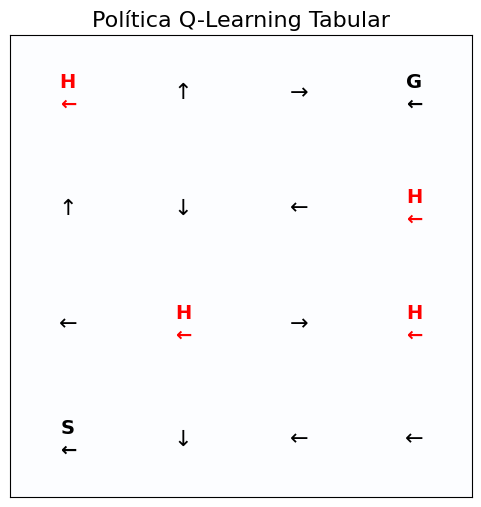

In [14]:

politica_qlearning = agente_qlearning.obtener_politica()
visualizar_politica(politica_qlearning, "Política Q-Learning Tabular")

## Visualizar tabla Q como heatmap

Este gráfico permite visualizar claramente cómo el agente valora cada acción en cada estado. Los valores Q más altos indican acciones preferidas para cada estado, lo que ayuda a interpretar y analizar la política que el agente ha aprendido.

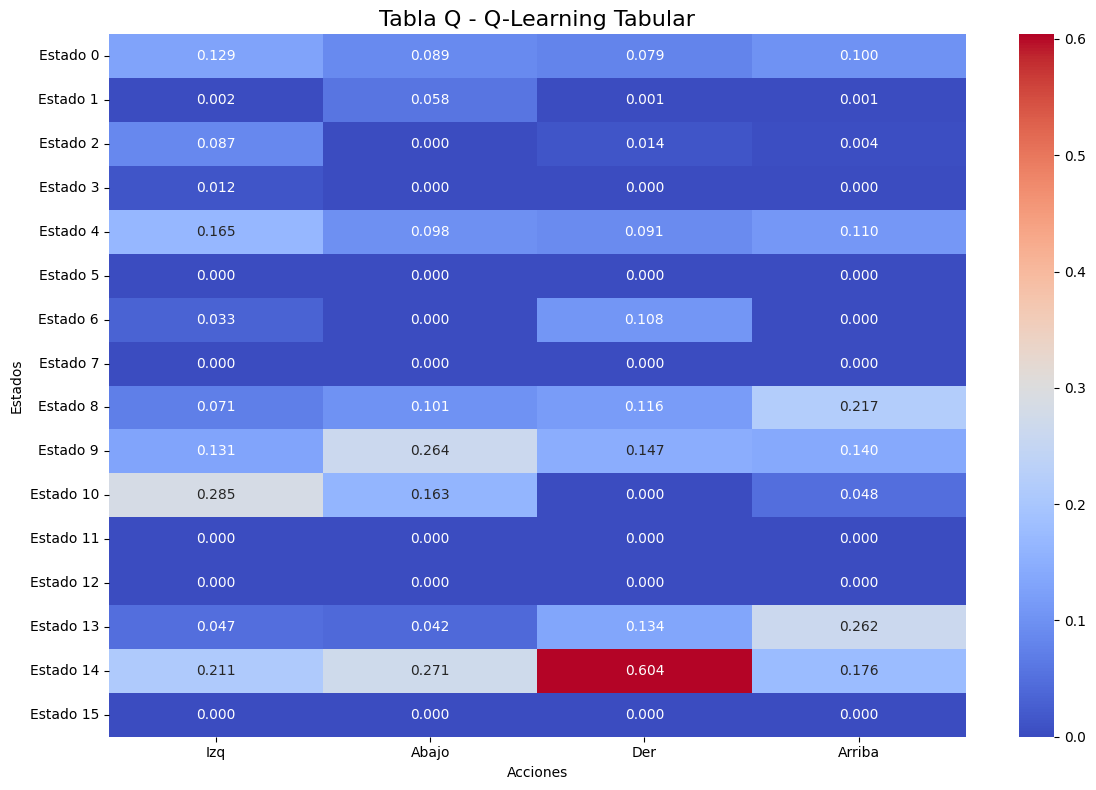

In [15]:

plt.figure(figsize=(12, 8))
sns.heatmap(agente_qlearning.q_table, annot=True, fmt='.3f', cmap='coolwarm',
xticklabels=['Izq', 'Abajo', 'Der', 'Arriba'],
yticklabels=[f'Estado {i}' for i in range(16)])
plt.title('Tabla Q - Q-Learning Tabular', fontsize=16)
plt.xlabel('Acciones')
plt.ylabel('Estados')
plt.tight_layout()
plt.show()

## Mostrar valores Q para estados importantes
-
Este código permite examinar de forma clara y detallada cómo el agente valora las acciones en ciertos estados importantes dentro del entorno, facilitando la interpretación del aprendizaje obtenido y la evaluación de la política aprendida.

- Define una lista con los estados que queremos inspeccionar: el inicio (0), agujeros (5, 7, 11, 12), el estado final o meta (15) y un estado normal (14).

- Define una lista con nombres descriptivos para las acciones posibles, que serán usadas al mostrar los valores Q.

- Para cada estado clave, se asigna un tipo descriptivo para facilitar la interpretación:

"START" para el estado 0 (inicio).

"GOAL" para el estado 15 (meta).

"HOLE" para estados que representan agujeros o peligros.

"NORMAL" para cualquier otro estado.

- Imprime la línea con el número del estado y su tipo.

 Luego itera sobre todas las acciones disponibles para ese estado.

 Imprime el nombre de cada acción junto con su valor Q formateado con tres decimales.

 Esto muestra qué valor asigna el agente a cada acción desde ese estado, ayudando a entender su política y preferencias.




In [16]:
print("🎯 VALORES Q PARA ESTADOS CLAVE:")
print("-" * 40)
estados_clave = [0, 5, 7, 11, 12, 14, 15]  # Start, Holes, Goal
acciones_nombres = ['Izquierda', 'Abajo', 'Derecha', 'Arriba']
for estado in estados_clave:
  if estado == 0:
    tipo = "START"
  elif estado == 15:
    tipo = "GOAL"
  elif estado in [5, 7, 11, 12]:
    tipo = "HOLE"
  else:
    tipo = "NORMAL"

  print(f"\nEstado {estado} ({tipo}):")
  for accion, valor in enumerate(agente_qlearning.q_table[estado]):
     print(f"  {acciones_nombres[accion]}: {valor:.3f}")

🎯 VALORES Q PARA ESTADOS CLAVE:
----------------------------------------

Estado 0 (START):
  Izquierda: 0.129
  Abajo: 0.089
  Derecha: 0.079
  Arriba: 0.100

Estado 5 (HOLE):
  Izquierda: 0.000
  Abajo: 0.000
  Derecha: 0.000
  Arriba: 0.000

Estado 7 (HOLE):
  Izquierda: 0.000
  Abajo: 0.000
  Derecha: 0.000
  Arriba: 0.000

Estado 11 (HOLE):
  Izquierda: 0.000
  Abajo: 0.000
  Derecha: 0.000
  Arriba: 0.000

Estado 12 (HOLE):
  Izquierda: 0.000
  Abajo: 0.000
  Derecha: 0.000
  Arriba: 0.000

Estado 14 (NORMAL):
  Izquierda: 0.211
  Abajo: 0.271
  Derecha: 0.604
  Arriba: 0.176

Estado 15 (GOAL):
  Izquierda: 0.000
  Abajo: 0.000
  Derecha: 0.000
  Arriba: 0.000


En Q-Learning, cuando un estado es terminal (como la meta), no hay más recompensas futuras porque el episodio termina allí.

Por eso, el valor esperado de tomar cualquier acción en ese estado terminal es 0 (no hay ganancia futura).

En otras palabras, no importa qué acción tomes en el estado meta porque el episodio ya terminó, así que el valor Q se mantiene en 0.

# Deep Q-Network

## red DQN

- Se define una clase DQN que hereda de `torch.nn.Module`, lo que indica que es una red neuronal construida con PyTorch.
- Constructor de la red:

`input_size`: cantidad de entradas (dimensión del estado).

`hidden_size`: cantidad de neuronas en las capas ocultas.

`output_size`: cantidad de salidas (acciones posibles).

`super().__init__()` llama al constructor de la clase base nn.Module.

- Se define el modelo como una red neuronal secuencial, que contiene:

-- Una capa lineal (fully connected) de entrada → capa oculta.

-- Una función de activación ReLU.

-- Otra capa lineal oculta → oculta.

-- Otra ReLU.

-- Una capa final que produce `output_size` valores, correspondientes a los Q-valores para cada acción.

- Se define el método `forward()`, que realiza la propagación hacia adelante. Recibe un tensor x (el estado) y retorna el vector de Q-valores estimados para ese estado.

In [17]:
class DQN(nn.Module):
  """Red neuronal para aproximar la función Q"""
  def __init__(self, input_size, hidden_size, output_size):
      super(DQN, self).__init__()
      self.network = nn.Sequential(
          nn.Linear(input_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, output_size)
      )

  def forward(self, x):
      return self.network(x)

## DQNAgent

1. Define los hiperparámetros iniciales:

`state_size`: tamaño del espacio de estados.

`action_size`: cantidad de acciones posibles.

`lr`: tasa de aprendizaje.

`gamma`: factor de descuento.

`epsilon`: para la política ε-greedy (exploración).

También se inicializa el nombre para propósitos de logging.
2.  Usa GPU si está disponible, si no, CPU.
3. Redes Neuronales:

`q_network`:red principal que aprende los Q-valores.

`target_network`: red objetivo, actualizada cada N pasos.

Se usa `Adam` como optimizador.

Inicializa la target network con los mismos pesos que la red principal.
4. Replay memory y control de mantenimiento:

`memory`: almacén de experiencias pasadas (estado, acción, recompensa, siguiente estado, terminado).

Se usa para experience replay, lo cual rompe la correlación temporal entre muestras.

Controla cada cuántos pasos se actualiza la `target_network`.
5. Entrada `state_to_onehot`:
Convierte un estado discreto (por ejemplo, un número entre 0 y 15) en un vector one-hot de tamaño `state_size`.
6. `def remember`: Guarda una transición en la memoria de experiencia.

Convierte tanto el estado como el siguiente estado a one-hot antes de almacenarlos.
7. `def seleccionar_accion`: Si `entrenando=True` y con probabilidad `epsilon`, elige acción aleatoria.

Si no, elige la acción con mayor valor Q estimado por la red.
8. `Replay`: Este método es el núcleo del entrenamiento.

Muestra un batch aleatorio de experiencias.

Calcula los `Q(s,a)` actuales con `q_network`.

Calcula los `Q(s',a')` del siguiente estado con `target_network` (sin gradiente).

Usa la fórmula de Bellman para obtener el valor objetivo.

Calcula la pérdida (MSE) y realiza backpropagation.
9. Actualizacion de la target network: Copia los pesos de la red principal a la red objetivo.
10. Decaemiento de `epsilon`: Reduce el valor de epsilon en cada episodio, hasta `epsilon_min`
11. Politica Greedy final: Devuelve la política aprendida: la mejor acción para cada estado, sin explorar.
12. `entrenar`: Para cada episodio:

Reinicia el entorno.

Ejecuta el ciclo de selección → acción → almacenamiento → entrenamiento (`replay`).

Cada `N` pasos, actualiza la target network.

Guarda métricas: recompensas, tasa de éxito, `epsilon`, pérdida.

Aplica `decay_epsilon`.
13. `evaluar`: Ejecuta `episodios` sin exploración (`epsilon = 0`) y mide:

Tasa de éxito.

Recompensas acumuladas.

Promedio de pasos.
14. Visualización de la arquitectura:

              Estado (entero) ─→ one-hot ─→ q_network ─→ Q(s, a)
                               ↓
                           Acción greedy / aleatoria
                               ↓
                          Siguiente estado
                               ↓
                  Guardar experiencia (replay memory)
                               ↓
                 Entrenamiento con batches aleatorios
                               ↓
                   Actualización de red objetivo


In [18]:
class DQNAgent:
  """Agente Deep Q-Network con Experience Replay y Target Network"""
  def __init__(self, state_size, action_size, lr=0.001, gamma=0.95, epsilon=1.0):
      self.state_size = state_size
      self.action_size = action_size
      self.gamma = gamma
      self.epsilon = epsilon
      self.epsilon_decay = 0.995
      self.epsilon_min = 0.01
      self.learning_rate = lr
      self.nombre = "Deep Q-Network (DQN)"

      # Configuración del dispositivo
      self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
      print(f"🖥️ Usando dispositivo: {self.device}")

      # Redes neuronales
      hidden_size = 128
      self.q_network = DQN(state_size, hidden_size, action_size).to(self.device)
      self.target_network = DQN(state_size, hidden_size, action_size).to(self.device)
      self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

      # Inicializar target network con mismos pesos
      self.update_target_network()

      # Experience Replay
      self.memory = deque(maxlen=10000)
      self.batch_size = 32

      # Frecuencia de actualización de target network
      self.update_target_frequency = 100
      self.step_count = 0

      # Para tracking
      self.losses = []
      self.recompensas_entrenamiento = []
      self.epsilons = []

  def state_to_onehot(self, state):
      """Convertir estado discreto a representación one-hot"""
      onehot = np.zeros(self.state_size)
      onehot[state] = 1.0
      return onehot

  def remember(self, estado, accion, recompensa, siguiente_estado, terminado):
      """Almacenar experiencia en el buffer de replay"""
      estado_onehot = self.state_to_onehot(estado)
      siguiente_estado_onehot = self.state_to_onehot(siguiente_estado)

      self.memory.append((estado_onehot, accion, recompensa, siguiente_estado_onehot, terminado))

  def seleccionar_accion(self, estado, entrenando=True):
      """Selección de acción epsilon-greedy usando la red neuronal"""
      if entrenando and np.random.random() < self.epsilon:
          return random.randrange(self.action_size)

      # Convertir estado a tensor
      estado_onehot = self.state_to_onehot(estado)
      estado_tensor = torch.FloatTensor(estado_onehot).unsqueeze(0).to(self.device)

      # Forward pass
      with torch.no_grad():
          q_values = self.q_network(estado_tensor)

      return np.argmax(q_values.cpu().data.numpy())

  def replay(self):
      """Experience replay para entrenar la red"""
      if len(self.memory) < self.batch_size:
          return

      # Muestrear batch aleatorio
      batch = random.sample(self.memory, self.batch_size)
      estados = torch.FloatTensor([e[0] for e in batch]).to(self.device)
      acciones = torch.LongTensor([e[1] for e in batch]).to(self.device)
      recompensas = torch.FloatTensor([e[2] for e in batch]).to(self.device)
      siguientes_estados = torch.FloatTensor([e[3] for e in batch]).to(self.device)
      terminados = torch.BoolTensor([e[4] for e in batch]).to(self.device)

      # Q-values actuales
      current_q_values = self.q_network(estados).gather(1, acciones.unsqueeze(1))

      # Q-values objetivo usando target network
      with torch.no_grad():
          next_q_values = self.target_network(siguientes_estados).max(1)[0]
          target_q_values = recompensas + (self.gamma * next_q_values * ~terminados)

      # Calcular pérdida
      loss = F.mse_loss(current_q_values.squeeze(), target_q_values)

      # Backpropagation
      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

      # Guardar pérdida para análisis
      self.losses.append(loss.item())

  def update_target_network(self):
      """Actualizar la target network con pesos de la red principal"""
      self.target_network.load_state_dict(self.q_network.state_dict())

  def decay_epsilon(self):
      """Reducir epsilon gradualmente"""
      if self.epsilon > self.epsilon_min:
          self.epsilon *= self.epsilon_decay

  def obtener_politica(self):
      """Obtener política greedy de la red entrenada"""
      politica = []
      for estado in range(self.state_size):
          accion = self.seleccionar_accion(estado, entrenando=False)
          politica.append(accion)
      return np.array(politica)

  def entrenar(self, env, episodios=2000):
      """Entrenamiento del agente DQN"""
      print(f"🤖 Entrenando {self.nombre}...")

      recompensas = []
      exitos_ventana = deque(maxlen=100)

      for episodio in range(episodios):
          estado, _ = env.reset()
          recompensa_total = 0
          terminado = False
          pasos = 0

          while not terminado and pasos < 100:
              # Seleccionar acción
              accion = self.seleccionar_accion(estado, entrenando=True)

              # Ejecutar acción
              siguiente_estado, recompensa, terminado, truncated, _ = env.step(accion)

              if truncated:
                  terminado = True

              # Almacenar experiencia
              self.remember(estado, accion, recompensa, siguiente_estado, terminado)

              # Entrenar la red
              self.replay()

              recompensa_total += recompensa
              estado = siguiente_estado
              pasos += 1
              self.step_count += 1

              # Actualizar target network periódicamente
              if self.step_count % self.update_target_frequency == 0:
                  self.update_target_network()

          # Tracking
          recompensas.append(recompensa_total)
          exitos_ventana.append(1 if recompensa_total > 0 else 0)
          self.epsilons.append(self.epsilon)

          # Decay epsilon
          self.decay_epsilon()

          # Logging
          if (episodio + 1) % 200 == 0:
              tasa_exito = np.mean(exitos_ventana) if len(exitos_ventana) > 0 else 0
              loss_promedio = np.mean(self.losses[-100:]) if len(self.losses) > 0 else 0
              print(f"Episodio {episodio + 1}: Tasa éxito = {tasa_exito:.3f}, "
                    f"Epsilon = {self.epsilon:.3f}, Loss = {loss_promedio:.4f}")

      self.recompensas_entrenamiento = recompensas
      print(f"\n✅ Entrenamiento {self.nombre} completado!")

      return recompensas

  def evaluar(self, env, episodios=100):
      """Evaluación del agente entrenado"""
      print(f"📊 Evaluando {self.nombre}...")

      exitos = 0
      recompensas = []
      pasos_totales = []

      for _ in range(episodios):
          estado, _ = env.reset()
          recompensa_total = 0
          terminado = False
          pasos = 0

          while not terminado and pasos < 100:
              accion = self.seleccionar_accion(estado, entrenando=False)
              estado, recompensa, terminado, truncated, _ = env.step(accion)

              if truncated:
                  terminado = True

              recompensa_total += recompensa
              pasos += 1

          if recompensa_total > 0:
              exitos += 1
          recompensas.append(recompensa_total)
          pasos_totales.append(pasos)

      tasa_exito = exitos / episodios
      print(f"Tasa de éxito: {tasa_exito:.3f}")
      print(f"Pasos promedio: {np.mean(pasos_totales):.1f}")

      return tasa_exito, recompensas

## Entrenar deep DQN

Crea una instancia del agente DQN.

Usa el tamaño del espacio de observación (`state_size`) y del espacio de acción (`action_size`) del entorno `env`.

Define los hiperparámetros iniciales:

`lr` = 0.001: tasa de aprendizaje.

`gamma` = 0.95: factor de descuento.

`epsilon` = 1.0: política exploratoria inicial (100% aleatorio al principio).

Entrena el agente por 1000 episodios.

Almacena las recompensas por episodio en `recompensas_dqn`.

In [19]:
set_seed(env=env)
agente_dqn = DQNAgent(env.observation_space.n, env.action_space.n,
lr=0.001, gamma=0.95, epsilon=1.0)
recompensas_dqn = agente_dqn.entrenar(env, episodios=1000)

🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.060, Epsilon = 0.367, Loss = 0.0093
Episodio 400: Tasa éxito = 0.160, Epsilon = 0.135, Loss = 0.0076
Episodio 600: Tasa éxito = 0.320, Epsilon = 0.049, Loss = 0.0081
Episodio 800: Tasa éxito = 0.410, Epsilon = 0.018, Loss = 0.0078
Episodio 1000: Tasa éxito = 0.510, Epsilon = 0.010, Loss = 0.0094

✅ Entrenamiento Deep Q-Network (DQN) completado!


## Evaluar agente Deep DQN

Evalúa al agente DQN ya entrenado durante 1000 `episodios` y captura:

`tasa_exito_dqn`: la proporción de episodios en los que el agente llegó al objetivo (`recompensa > 0`).

El guion bajo (`_`) ignora las recompensas individuales por episodio, que también retorna la función.



In [20]:
set_seed(env=env)
tasa_exito_dqn_1000, _ = agente_dqn.evaluar(env, episodios=1000)


📊 Evaluando Deep Q-Network (DQN)...
Tasa de éxito: 0.607
Pasos promedio: 35.9


## Visualizar política aprendida

1. `politica_dqn = agente_dqn.obtener_politica()`:

Genera la política greedy del agente, es decir, elige la mejor acción para cada estado según la red neuronal entrenada.

Cómo lo hace:

Recorre todos los estados posibles.

Convierte cada estado a one-hot.

Usa la red `q_network` (la principal) para predecir los valores Q para cada acción.

Selecciona la acción con el mayor valor Q (argmax).

Resultado: un array como `array([1, 1, 1, 1, 0, 2, ...])` donde el índice representa el estado y el valor es la acción (0=Izquierda, 1=Abajo, 2=Derecha, 3=Arriba).

2. `visualizar_politica(politica_dqn, "Política Deep Q-Network (DQN)")`
Qué hace: muestra visualmente la política aprendida en una grilla 4x4.

Cómo lo hace:

Para cada celda (estado del entorno), dibuja una flecha apuntando en la dirección de la acción elegida por el agente.

Añade un título ("Política Deep Q-Network (DQN)").

3.
- Si el entrenamiento fue exitoso:

Verás flechas que forman caminos desde el estado 0 hasta el 15 (objetivo), evitando los agujeros.

Las flechas deberían guiar de forma segura hacia la esquina inferior derecha.

- Si el entrenamiento no fue efectivo:

Las flechas pueden parecer aleatorias o apuntar hacia los agujeros.

El agente puede haberse quedado atrapado en una política subóptima.



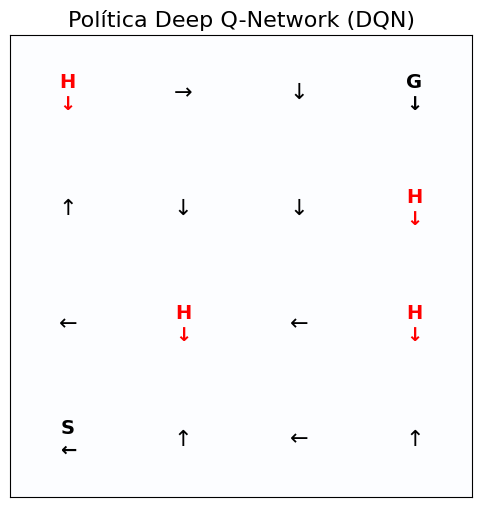

In [21]:

politica_dqn = agente_dqn.obtener_politica()
visualizar_politica(politica_dqn, "Política Deep Q-Network (DQN)")


# Comparación de resultados

## Comparación final tasa de éxito

In [22]:
print("🏆 COMPARACIÓN FINAL DE AGENTES")
print("=" * 50)
print(f"Política Aleatoria:    Tasa de éxito = {tasa_exito_aleatorio_1000:.3f}")
print(f"Q-Learning Tabular:    Tasa de éxito = {tasa_exito_qlearning_1000:.3f}")
print(f"Deep Q-Network (DQN):  Tasa de éxito = {tasa_exito_dqn_1000:.3f}")

🏆 COMPARACIÓN FINAL DE AGENTES
Política Aleatoria:    Tasa de éxito = 0.012
Q-Learning Tabular:    Tasa de éxito = 0.404
Deep Q-Network (DQN):  Tasa de éxito = 0.607


## Crear gráficas de comparación


Crear gráficas de comparación


### 1. Curvas de aprendizaje

In [ ]:
len(recompensas_aleatorio)

1000

In [ ]:
len(recompensas_qlearning)

1000

In [ ]:
len(recompensas_dqn)

1000

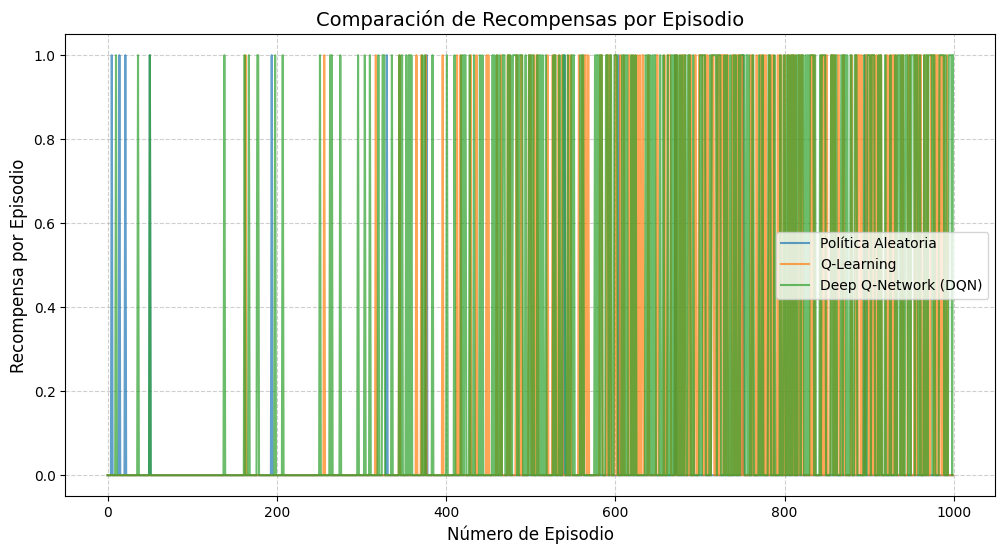

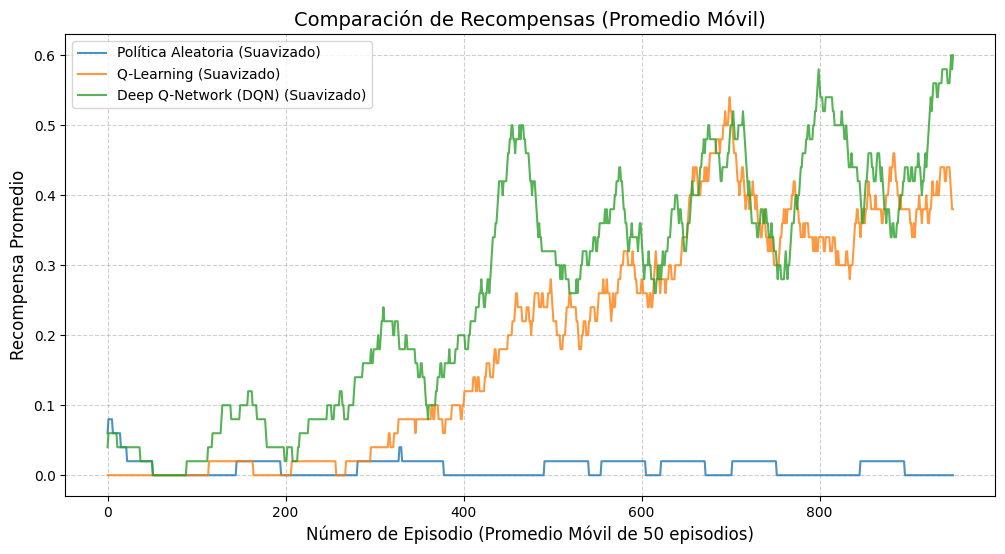

In [23]:
# prompt: crear gráfico que compare recompensas_aleatorio, recompensas_qlearning y recompensas_dqn. Eje x es nro de episodio y el eje Y valor de la recompensa

import matplotlib.pyplot as plt
import numpy as np
# Asegurar que las listas de recompensas tengan la misma longitud para la gráfica
# Tomaremos la longitud mínima si son diferentes
min_len = min(len(recompensas_aleatorio), len(recompensas_qlearning), len(recompensas_dqn))

plt.figure(figsize=(12, 6))
plt.plot(recompensas_aleatorio[:min_len], label='Política Aleatoria', alpha=0.7)
plt.plot(recompensas_qlearning[:min_len], label='Q-Learning', alpha=0.7)
plt.plot(recompensas_dqn[:min_len], label='Deep Q-Network (DQN)', alpha=0.7)

plt.xlabel('Número de Episodio', fontsize=12)
plt.ylabel('Recompensa por Episodio', fontsize=12)
plt.title('Comparación de Recompensas por Episodio', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Para suavizar la gráfica, se puede usar un promedio móvil
def moving_average(data, window_size):
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 50  # Tamaño de la ventana para el promedio móvil

recompensas_aleatorio_suavizado = moving_average(recompensas_aleatorio, window)
recompensas_qlearning_suavizado = moving_average(recompensas_qlearning, window)
recompensas_dqn_suavizado = moving_average(recompensas_dqn, window)

# Ajustar la longitud mínima para las series suavizadas
min_len_suavizado = min(len(recompensas_aleatorio_suavizado), len(recompensas_qlearning_suavizado), len(recompensas_dqn_suavizado))

plt.figure(figsize=(12, 6))
plt.plot(recompensas_aleatorio_suavizado[:min_len_suavizado], label='Política Aleatoria (Suavizado)', alpha=0.8)
plt.plot(recompensas_qlearning_suavizado[:min_len_suavizado], label='Q-Learning (Suavizado)', alpha=0.8)
plt.plot(recompensas_dqn_suavizado[:min_len_suavizado], label='Deep Q-Network (DQN) (Suavizado)', alpha=0.8)

plt.xlabel(f'Número de Episodio (Promedio Móvil de {window} episodios)', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title('Comparación de Recompensas (Promedio Móvil)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



### 2. Comparación de tasas de éxito

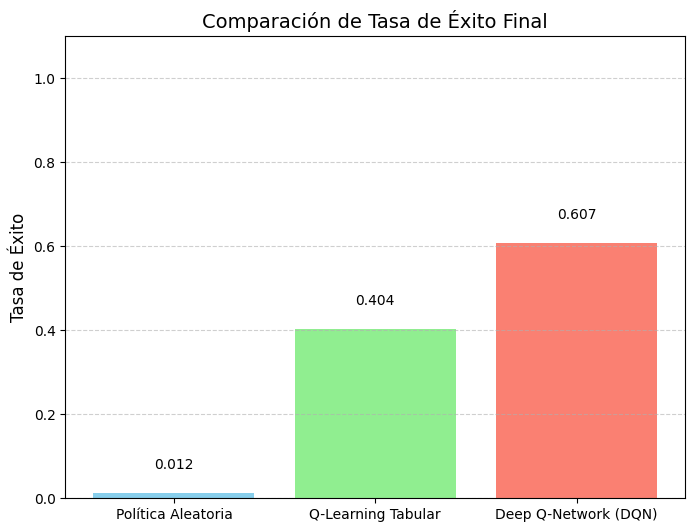

In [24]:
# prompt: comparar tasa_exito_aleatorio, tasa_exito_qlearning, tasa_exito_dqn en un gráfico de barras

import matplotlib.pyplot as plt
metricas = ['Política Aleatoria', 'Q-Learning Tabular', 'Deep Q-Network (DQN)']
tasas_exito = [tasa_exito_aleatorio_1000, tasa_exito_qlearning_1000, tasa_exito_dqn_1000]

plt.figure(figsize=(8, 6))
barras = plt.bar(metricas, tasas_exito, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Tasa de Éxito', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final', fontsize=14)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización

# Añadir los valores de las tasas de éxito encima de cada barra
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### Evolución de Epsilon (solo para algoritmos que usan exploración)

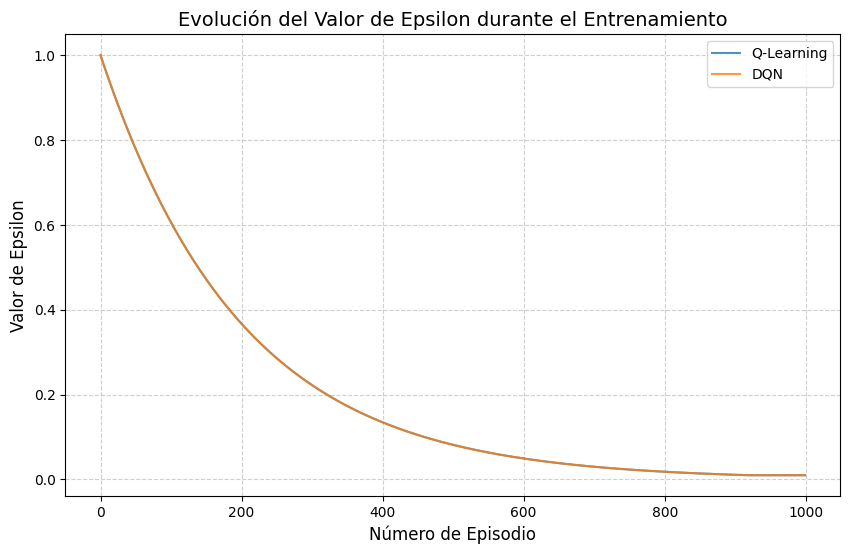

In [25]:
# prompt: Crear un gráfico para comparar agente_qlearning.epsilons y agente_qlearning.epsilons siendo x el nro de episodios y el eje Y el valor de epsilon

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(agente_qlearning.epsilons, label='Q-Learning', alpha=0.8)
plt.plot(agente_dqn.epsilons, label='DQN', alpha=0.8)

plt.xlabel('Número de Episodio', fontsize=12)
plt.ylabel('Valor de Epsilon', fontsize=12)
plt.title('Evolución del Valor de Epsilon durante el Entrenamiento', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### DQN pérdida

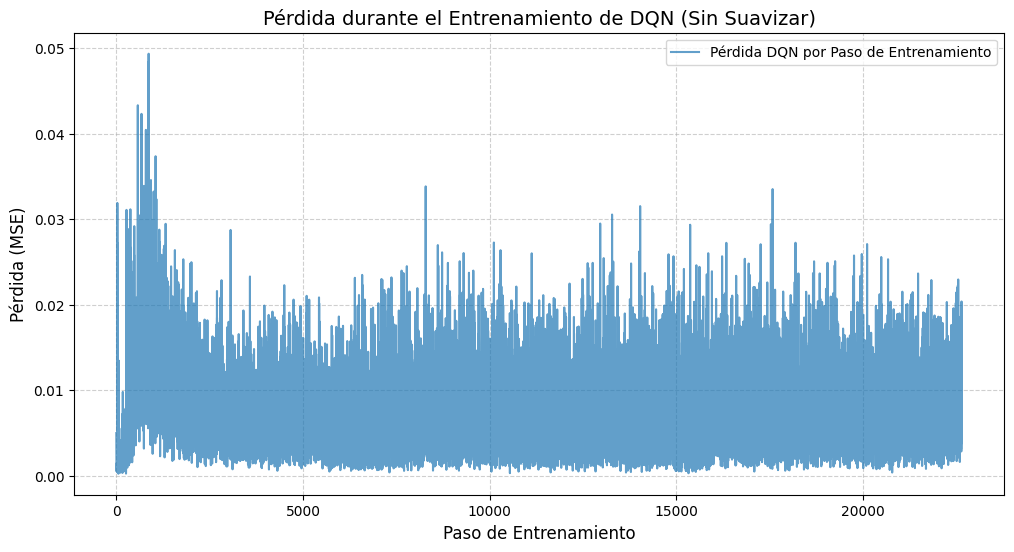

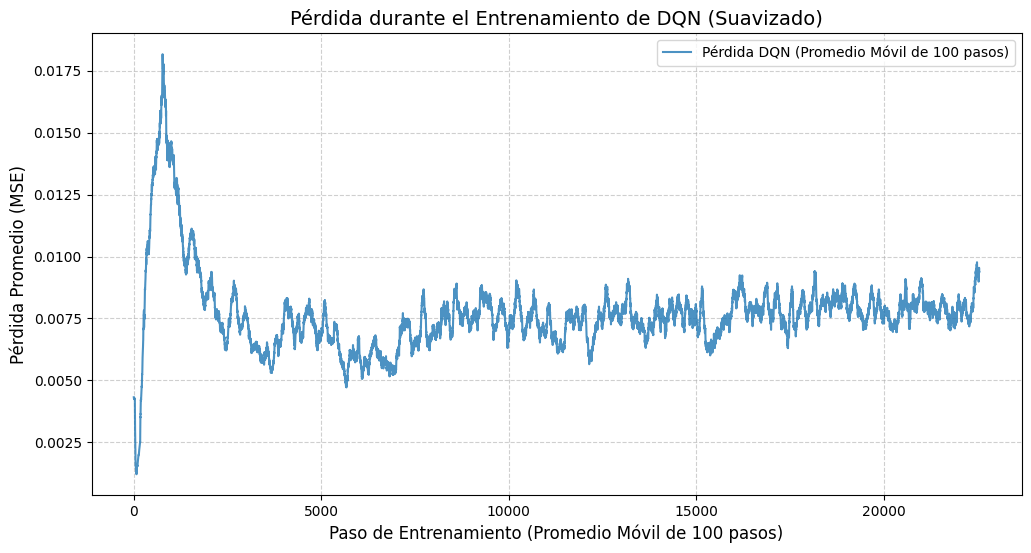

In [26]:
# prompt: Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con y sin promedio móvil

import matplotlib.pyplot as plt
# Graficar la pérdida del agente DQN
plt.figure(figsize=(12, 6))
plt.plot(agente_dqn.losses, label='Pérdida DQN por Paso de Entrenamiento', alpha=0.7)
plt.xlabel('Paso de Entrenamiento', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)
plt.title('Pérdida durante el Entrenamiento de DQN (Sin Suavizar)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Graficar la pérdida con promedio móvil para suavizar
window_loss = 100 # Tamaño de la ventana para el promedio móvil de la pérdida
losses_dqn_suavizado = moving_average(agente_dqn.losses, window_loss)

plt.figure(figsize=(12, 6))
plt.plot(losses_dqn_suavizado, label=f'Pérdida DQN (Promedio Móvil de {window_loss} pasos)', alpha=0.8)
plt.xlabel(f'Paso de Entrenamiento (Promedio Móvil de {window_loss} pasos)', fontsize=12)
plt.ylabel('Pérdida Promedio (MSE)', fontsize=12)
plt.title('Pérdida durante el Entrenamiento de DQN (Suavizado)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Ejercitación

## A) Modifique el entrenamiento de los agentes para entrenar por más episodios. Evalue su desempeño. ¿ Mejora o empeora ?






🎲 Evaluando Política Aleatoria...
Episodio 200: Tasa de éxito = 0.025
Episodio 400: Tasa de éxito = 0.018
Episodio 600: Tasa de éxito = 0.013
Episodio 800: Tasa de éxito = 0.014
Episodio 1000: Tasa de éxito = 0.012
Episodio 1200: Tasa de éxito = 0.013
Episodio 1400: Tasa de éxito = 0.015
Episodio 1600: Tasa de éxito = 0.014
Episodio 1800: Tasa de éxito = 0.014
Episodio 2000: Tasa de éxito = 0.015

📊 Resultados Política Aleatoria:
Tasa de éxito final: 0.015
Recompensa promedio: 0.015


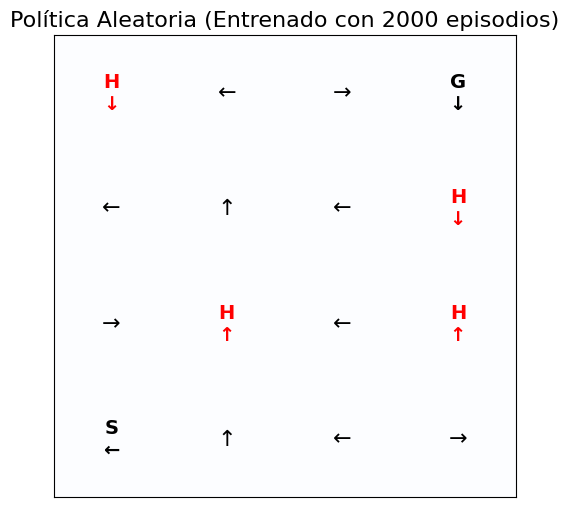

🧠 Entrenando Q-Learning Tabular...
Episodio 100: Tasa éxito (últimos 100) = 0.030, Epsilon = 0.606
Episodio 200: Tasa éxito (últimos 100) = 0.050, Epsilon = 0.367
Episodio 300: Tasa éxito (últimos 100) = 0.060, Epsilon = 0.222
Episodio 400: Tasa éxito (últimos 100) = 0.160, Epsilon = 0.135
Episodio 500: Tasa éxito (últimos 100) = 0.170, Epsilon = 0.082
Episodio 600: Tasa éxito (últimos 100) = 0.280, Epsilon = 0.049
Episodio 700: Tasa éxito (últimos 100) = 0.400, Epsilon = 0.030
Episodio 800: Tasa éxito (últimos 100) = 0.530, Epsilon = 0.018
Episodio 900: Tasa éxito (últimos 100) = 0.540, Epsilon = 0.011
Episodio 1000: Tasa éxito (últimos 100) = 0.480, Epsilon = 0.010
Episodio 1100: Tasa éxito (últimos 100) = 0.470, Epsilon = 0.010
Episodio 1200: Tasa éxito (últimos 100) = 0.560, Epsilon = 0.010
Episodio 1300: Tasa éxito (últimos 100) = 0.560, Epsilon = 0.010
Episodio 1400: Tasa éxito (últimos 100) = 0.550, Epsilon = 0.010
Episodio 1500: Tasa éxito (últimos 100) = 0.430, Epsilon = 0.010

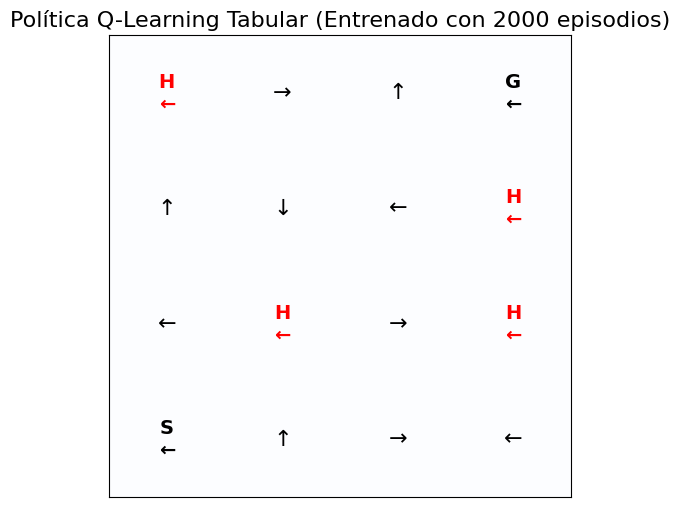

🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.060, Epsilon = 0.367, Loss = 0.0127
Episodio 400: Tasa éxito = 0.170, Epsilon = 0.135, Loss = 0.0069
Episodio 600: Tasa éxito = 0.430, Epsilon = 0.049, Loss = 0.0075
Episodio 800: Tasa éxito = 0.440, Epsilon = 0.018, Loss = 0.0068
Episodio 1000: Tasa éxito = 0.560, Epsilon = 0.010, Loss = 0.0076
Episodio 1200: Tasa éxito = 0.570, Epsilon = 0.010, Loss = 0.0088
Episodio 1400: Tasa éxito = 0.580, Epsilon = 0.010, Loss = 0.0082
Episodio 1600: Tasa éxito = 0.460, Epsilon = 0.010, Loss = 0.0077
Episodio 1800: Tasa éxito = 0.620, Epsilon = 0.010, Loss = 0.0071
Episodio 2000: Tasa éxito = 0.700, Epsilon = 0.010, Loss = 0.0084

✅ Entrenamiento Deep Q-Network (DQN) completado!
📊 Evaluando Deep Q-Network (DQN)...
Tasa de éxito: 0.726
Pasos promedio: 42.1


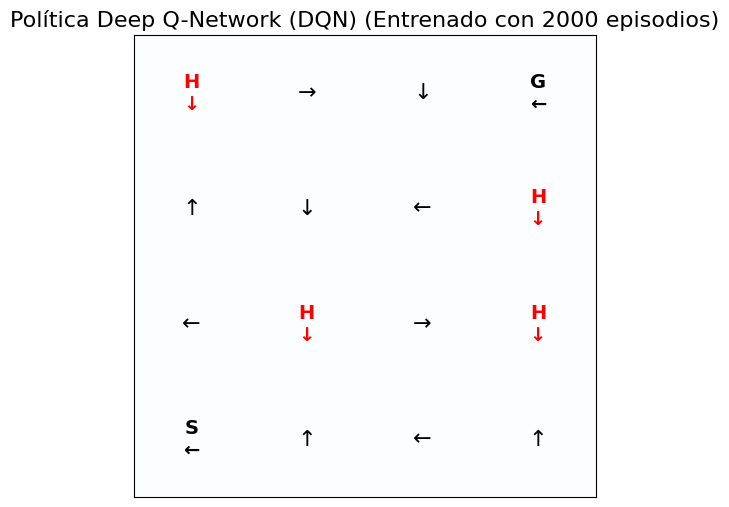


🏆 COMPARACIÓN FINAL DE AGENTES (Entrenados con 2000 episodios)
Política Aleatoria_2:    Tasa de éxito = 0.015
Q-Learning Tabular_2:    Tasa de éxito = 0.510
Deep Q-Network (DQN)_2:  Tasa de éxito = 0.726


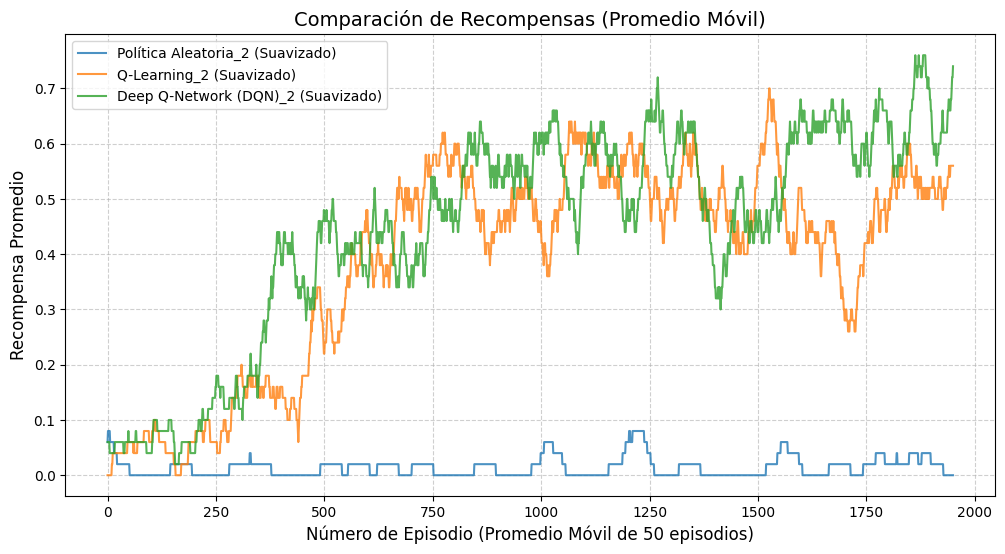

In [27]:
# prompt: como deberia modificar el codigo para crear una variable "episodios = x " y luego poder pasarle un parametro "episodios" a los agentes para que solo deba cambiarlo una vez en todo el codigo y se entrenen en base a el?
set_seed(env=env)

# Crear la variable episodios
episodios = 2000

# Modificar politica aleatoria
agente_aleatorio_2 = PoliticaAleatoria(env.action_space.n)
recompensas_aleatorio, tasa_exito_aleatorio_2000 = agente_aleatorio_2.entrenar(env, episodios=episodios)


politica_aleatoria = np.random.randint(0, 4, 16)  # Solo para visualización
visualizar_politica(politica_aleatoria, "Política Aleatoria (Entrenado con {} episodios)".format(episodios))

# Modificar el entrenamiento del agente Q-Learning
agente_qlearning_2 = QLearningTabular(env.observation_space.n, env.action_space.n,lr=0.1, gamma=0.95, epsilon=1.0)
recompensas_qlearning = agente_qlearning_2.entrenar(env, episodios=episodios) # Pasar la variable episodios

# Evaluar agente Q-Learning entrenado
tasa_exito_qlearning_2000, _ = agente_qlearning_2.evaluar(env, episodios=episodios) # Evaluación con un número fijo de episodios para consistencia

# Visualizar política aprendida Q-Learning
politica_qlearning = agente_qlearning_2.obtener_politica()
visualizar_politica(politica_qlearning, "Política Q-Learning Tabular (Entrenado con {} episodios)".format(episodios))

# Modificar el entrenamiento del agente Deep DQN
agente_dqn_2 = DQNAgent(env.observation_space.n, env.action_space.n,
lr=0.001, gamma=0.95, epsilon=1.0)
recompensas_dqn = agente_dqn_2.entrenar(env, episodios=episodios) # Pasar la variable episodios

# Evaluar agente Deep DQN entrenado
tasa_exito_dqn_2000, _ = agente_dqn_2.evaluar(env, episodios=episodios) # Evaluación con un número fijo de episodios para consistencia

# Visualizar política aprendida Deep DQN
politica_dqn = agente_dqn_2.obtener_politica()
visualizar_politica(politica_dqn, "Política Deep Q-Network (DQN) (Entrenado con {} episodios)".format(episodios))

# Comparación final tasa de éxito con el nuevo entrenamiento
print("\n🏆 COMPARACIÓN FINAL DE AGENTES (Entrenados con {} episodios)".format(episodios))
print("=" * 50)
# La política aleatoria no se entrena, así que su tasa de éxito no cambia
print(f"Política Aleatoria_2:    Tasa de éxito = {tasa_exito_aleatorio_2000:.3f}")
print(f"Q-Learning Tabular_2:    Tasa de éxito = {tasa_exito_qlearning_2000:.3f}")
print(f"Deep Q-Network (DQN)_2:  Tasa de éxito = {tasa_exito_dqn_2000:.3f}")



#  gráfica de recompensas suavizadas:
min_len_suavizado = min(len(moving_average(recompensas_aleatorio, window)), len(moving_average(recompensas_qlearning, window)), len(moving_average(recompensas_dqn, window)))

plt.figure(figsize=(12, 6))
plt.plot(moving_average(recompensas_aleatorio, window)[:min_len_suavizado], label='Política Aleatoria_2 (Suavizado)', alpha=0.8)
plt.plot(moving_average(recompensas_qlearning, window)[:min_len_suavizado], label='Q-Learning_2 (Suavizado)', alpha=0.8)
plt.plot(moving_average(recompensas_dqn, window)[:min_len_suavizado], label='Deep Q-Network (DQN)_2 (Suavizado)', alpha=0.8)

plt.xlabel(f'Número de Episodio (Promedio Móvil de {window} episodios)', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title('Comparación de Recompensas (Promedio Móvil)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



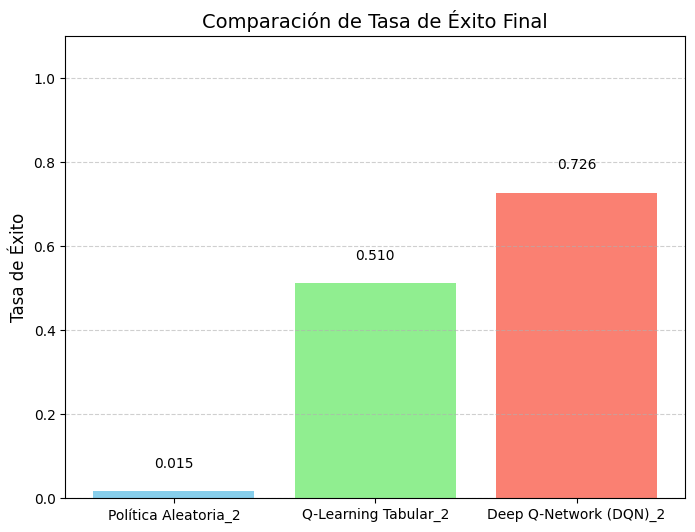

In [28]:
# prompt: agrega el politica aleatoria tambien a la comparacion

metricas = ['Política Aleatoria_2', 'Q-Learning Tabular_2', 'Deep Q-Network (DQN)_2']
tasas_exito = [tasa_exito_aleatorio_2000, tasa_exito_qlearning_2000, tasa_exito_dqn_2000]

plt.figure(figsize=(8, 6))
barras = plt.bar(metricas, tasas_exito, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Tasa de Éxito', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final', fontsize=14)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización

# Añadir los valores de las tasas de éxito encima de cada barra
for bar in barras:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


🎲 Evaluando Política Aleatoria...
Episodio 200: Tasa de éxito = 0.025
Episodio 400: Tasa de éxito = 0.018
Episodio 600: Tasa de éxito = 0.013
Episodio 800: Tasa de éxito = 0.014
Episodio 1000: Tasa de éxito = 0.012
Episodio 1200: Tasa de éxito = 0.013
Episodio 1400: Tasa de éxito = 0.015
Episodio 1600: Tasa de éxito = 0.014
Episodio 1800: Tasa de éxito = 0.014
Episodio 2000: Tasa de éxito = 0.015
Episodio 2200: Tasa de éxito = 0.016
Episodio 2400: Tasa de éxito = 0.016
Episodio 2600: Tasa de éxito = 0.016
Episodio 2800: Tasa de éxito = 0.015
Episodio 3000: Tasa de éxito = 0.014

📊 Resultados Política Aleatoria:
Tasa de éxito final: 0.014
Recompensa promedio: 0.014


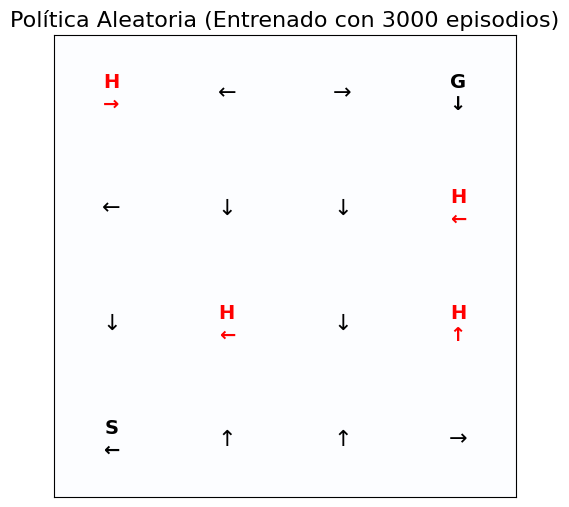

🧠 Entrenando Q-Learning Tabular...
Episodio 100: Tasa éxito (últimos 100) = 0.010, Epsilon = 0.606
Episodio 200: Tasa éxito (últimos 100) = 0.010, Epsilon = 0.367
Episodio 300: Tasa éxito (últimos 100) = 0.030, Epsilon = 0.222
Episodio 400: Tasa éxito (últimos 100) = 0.030, Epsilon = 0.135
Episodio 500: Tasa éxito (últimos 100) = 0.050, Epsilon = 0.082
Episodio 600: Tasa éxito (últimos 100) = 0.110, Epsilon = 0.049
Episodio 700: Tasa éxito (últimos 100) = 0.130, Epsilon = 0.030
Episodio 800: Tasa éxito (últimos 100) = 0.080, Epsilon = 0.018
Episodio 900: Tasa éxito (últimos 100) = 0.170, Epsilon = 0.011
Episodio 1000: Tasa éxito (últimos 100) = 0.130, Epsilon = 0.010
Episodio 1100: Tasa éxito (últimos 100) = 0.100, Epsilon = 0.010
Episodio 1200: Tasa éxito (últimos 100) = 0.130, Epsilon = 0.010
Episodio 1300: Tasa éxito (últimos 100) = 0.130, Epsilon = 0.010
Episodio 1400: Tasa éxito (últimos 100) = 0.060, Epsilon = 0.010
Episodio 1500: Tasa éxito (últimos 100) = 0.110, Epsilon = 0.010

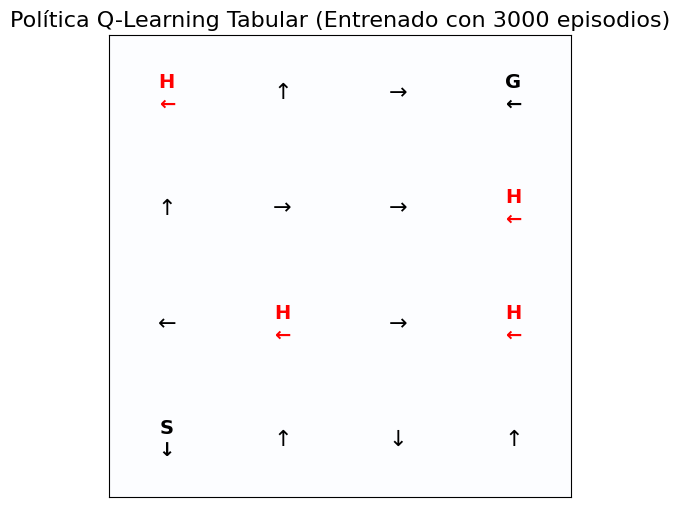

🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.070, Epsilon = 0.367, Loss = 0.0086
Episodio 400: Tasa éxito = 0.170, Epsilon = 0.135, Loss = 0.0072
Episodio 600: Tasa éxito = 0.310, Epsilon = 0.049, Loss = 0.0072
Episodio 800: Tasa éxito = 0.520, Epsilon = 0.018, Loss = 0.0062
Episodio 1000: Tasa éxito = 0.590, Epsilon = 0.010, Loss = 0.0078
Episodio 1200: Tasa éxito = 0.520, Epsilon = 0.010, Loss = 0.0080
Episodio 1400: Tasa éxito = 0.410, Epsilon = 0.010, Loss = 0.0073
Episodio 1600: Tasa éxito = 0.540, Epsilon = 0.010, Loss = 0.0065
Episodio 1800: Tasa éxito = 0.700, Epsilon = 0.010, Loss = 0.0080
Episodio 2000: Tasa éxito = 0.580, Epsilon = 0.010, Loss = 0.0074
Episodio 2200: Tasa éxito = 0.550, Epsilon = 0.010, Loss = 0.0089
Episodio 2400: Tasa éxito = 0.690, Epsilon = 0.010, Loss = 0.0080
Episodio 2600: Tasa éxito = 0.510, Epsilon = 0.010, Loss = 0.0075
Episodio 2800: Tasa éxito = 0.630, Epsilon = 0.010, Loss = 0.0082
Episodio 3000: T

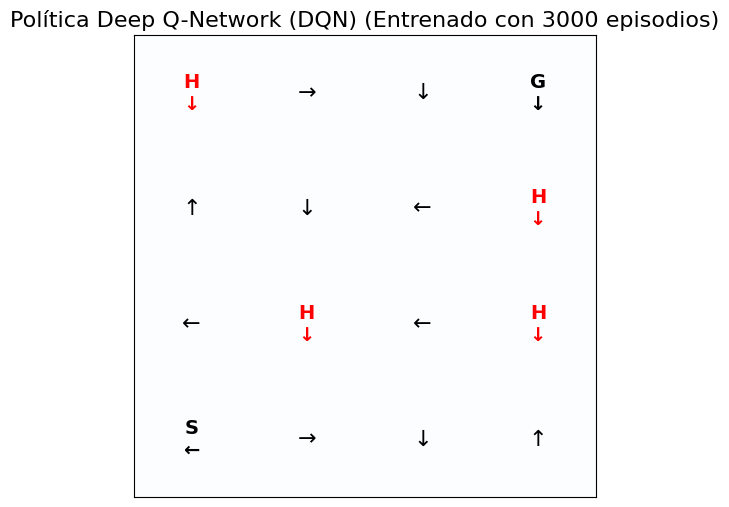


🏆 COMPARACIÓN FINAL DE AGENTES (Entrenados con 3000 episodios)
Política Aleatoria_3:    Tasa de éxito = 0.014
Q-Learning Tabular_3:    Tasa de éxito = 0.153
Deep Q-Network (DQN)_3:  Tasa de éxito = 0.693


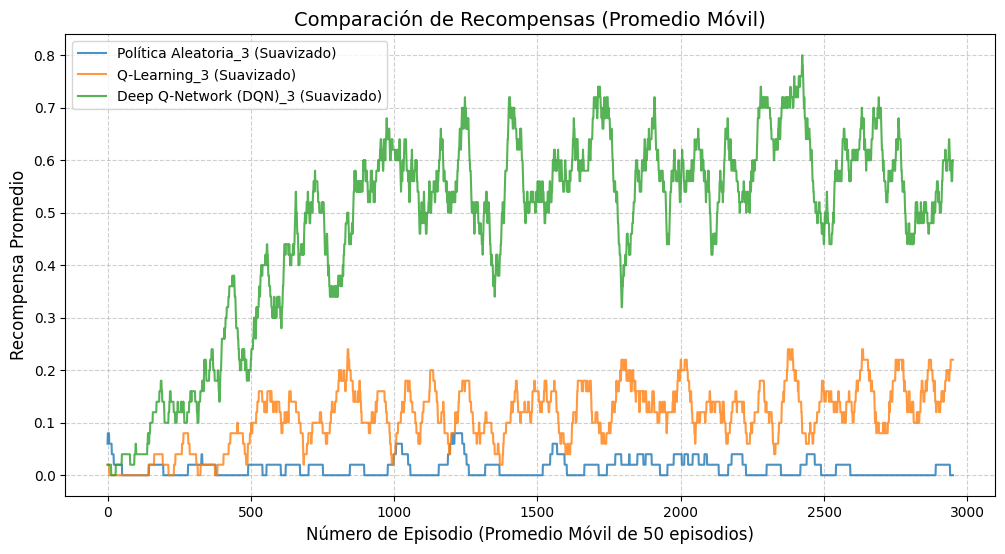

In [29]:

set_seed(env=env)

# Crear la variable episodios
episodios = 3000

# Modificar politica aleatoria
agente_aleatorio_3 = PoliticaAleatoria(env.action_space.n)
recompensas_aleatorio, tasa_exito_aleatorio_3000 = agente_aleatorio_3.entrenar(env, episodios=episodios)


politica_aleatoria = np.random.randint(0, 4, 16)  # Solo para visualización
visualizar_politica(politica_aleatoria, "Política Aleatoria (Entrenado con {} episodios)".format(episodios))

# Modificar el entrenamiento del agente Q-Learning
agente_qlearning_3 = QLearningTabular(env.observation_space.n, env.action_space.n,lr=0.1, gamma=0.95, epsilon=1.0)
recompensas_qlearning = agente_qlearning_3.entrenar(env, episodios=episodios) # Pasar la variable episodios

# Evaluar agente Q-Learning entrenado
tasa_exito_qlearning_3000, _ = agente_qlearning_3.evaluar(env, episodios=episodios) # Evaluación con un número fijo de episodios para consistencia

# Visualizar política aprendida Q-Learning
politica_qlearning = agente_qlearning_3.obtener_politica()
visualizar_politica(politica_qlearning, "Política Q-Learning Tabular (Entrenado con {} episodios)".format(episodios))

# Modificar el entrenamiento del agente Deep DQN
agente_dqn_3 = DQNAgent(env.observation_space.n, env.action_space.n,
lr=0.001, gamma=0.95, epsilon=1.0)
recompensas_dqn = agente_dqn_3.entrenar(env, episodios=episodios) # Pasar la variable episodios

# Evaluar agente Deep DQN entrenado
tasa_exito_dqn_3000, _ = agente_dqn_3.evaluar(env, episodios=episodios) # Evaluación con un número fijo de episodios para consistencia

# Visualizar política aprendida Deep DQN
politica_dqn = agente_dqn_3.obtener_politica()
visualizar_politica(politica_dqn, "Política Deep Q-Network (DQN) (Entrenado con {} episodios)".format(episodios))

# Comparación final tasa de éxito con el nuevo entrenamiento
print("\n🏆 COMPARACIÓN FINAL DE AGENTES (Entrenados con {} episodios)".format(episodios))
print("=" * 50)
# La política aleatoria no se entrena, así que su tasa de éxito no cambia
print(f"Política Aleatoria_3:    Tasa de éxito = {tasa_exito_aleatorio_3000:.3f}")
print(f"Q-Learning Tabular_3:    Tasa de éxito = {tasa_exito_qlearning_3000:.3f}")
print(f"Deep Q-Network (DQN)_3:  Tasa de éxito = {tasa_exito_dqn_3000:.3f}")

# Puedes volver a generar las gráficas de comparación si deseas ver el efecto de más episodios
# en las curvas de aprendizaje, evolución de epsilon y pérdida.
# Por ejemplo, la gráfica de recompensas suavizadas:
min_len_suavizado = min(len(moving_average(recompensas_aleatorio, window)), len(moving_average(recompensas_qlearning, window)), len(moving_average(recompensas_dqn, window)))

plt.figure(figsize=(12, 6))
plt.plot(moving_average(recompensas_aleatorio, window)[:min_len_suavizado], label='Política Aleatoria_3 (Suavizado)', alpha=0.8)
plt.plot(moving_average(recompensas_qlearning, window)[:min_len_suavizado], label='Q-Learning_3 (Suavizado)', alpha=0.8)
plt.plot(moving_average(recompensas_dqn, window)[:min_len_suavizado], label='Deep Q-Network (DQN)_3 (Suavizado)', alpha=0.8)

plt.xlabel(f'Número de Episodio (Promedio Móvil de {window} episodios)', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title('Comparación de Recompensas (Promedio Móvil)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



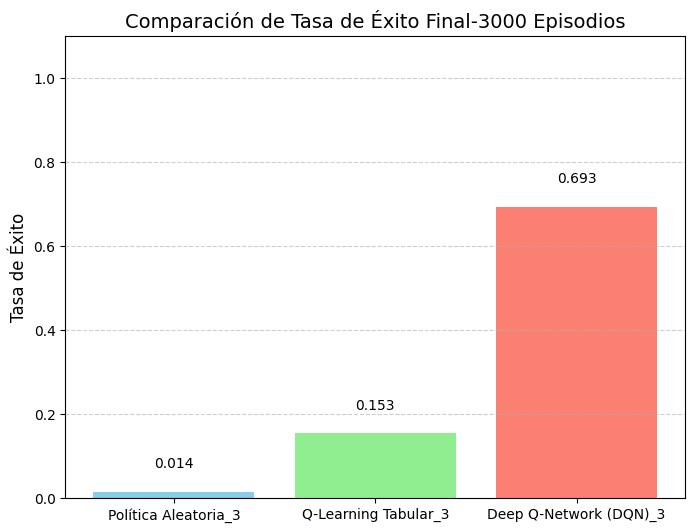

In [30]:
# prompt: agrega el politica aleatoria tambien a la comparacion

metricas = ['Política Aleatoria_3', 'Q-Learning Tabular_3', 'Deep Q-Network (DQN)_3']
tasas_exito = [tasa_exito_aleatorio_3000, tasa_exito_qlearning_3000, tasa_exito_dqn_3000]

plt.figure(figsize=(8, 6))
barras = plt.bar(metricas, tasas_exito, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Tasa de Éxito', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final-3000 Episodios', fontsize=14)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización

# Añadir los valores de las tasas de éxito encima de cada barra
for bar in barras:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


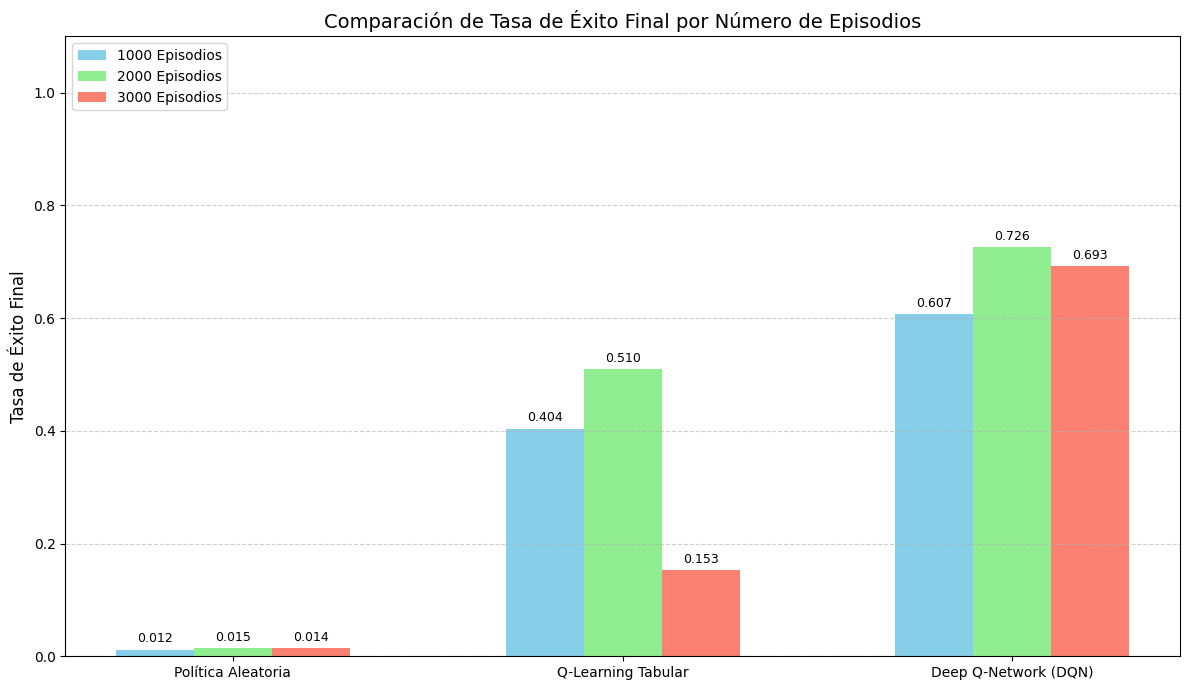

In [31]:
# prompt: Genera un grafico de barras comparativo entre los 3 modelos, comparando la tasa de éxito final en los entrenamientos de 1000, 2000 y 3000 episodios. Para ello coloqué nombres diferentes a las variables de tasa de éxito final (finalizan en _1000, _2000 y _3000 respectivamente para identificarlas)

# Datos para la gráfica de barras comparativa
modelos = ['Política Aleatoria', 'Q-Learning Tabular', 'Deep Q-Network (DQN)']
episodios_labels = ['1000 Episodios', '2000 Episodios', '3000 Episodios']

# Crear listas con las tasas de éxito para cada número de episodios
tasas_exito_1000 = [tasa_exito_aleatorio_1000, tasa_exito_qlearning_1000, tasa_exito_dqn_1000]
tasas_exito_2000 = [tasa_exito_aleatorio_2000, tasa_exito_qlearning_2000, tasa_exito_dqn_2000]
tasas_exito_3000 = [tasa_exito_aleatorio_3000, tasa_exito_qlearning_3000, tasa_exito_dqn_3000]

x = np.arange(len(modelos))  # Posiciones para los grupos de barras
width = 0.2  # Ancho de las barras

plt.figure(figsize=(12, 7))

# Crear las barras para cada número de episodios
rects1 = plt.bar(x - width, tasas_exito_1000, width, label=episodios_labels[0], color='skyblue')
rects2 = plt.bar(x, tasas_exito_2000, width, label=episodios_labels[1], color='lightgreen')
rects3 = plt.bar(x + width, tasas_exito_3000, width, label=episodios_labels[2], color='salmon')

# Añadir etiquetas, título y ticks
plt.ylabel('Tasa de Éxito Final', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final por Número de Episodios', fontsize=14)
plt.xticks(x, modelos)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización
plt.legend(loc='upper left')

# Función para añadir etiquetas de valor en cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Añadir etiquetas de valor en todas las barras
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


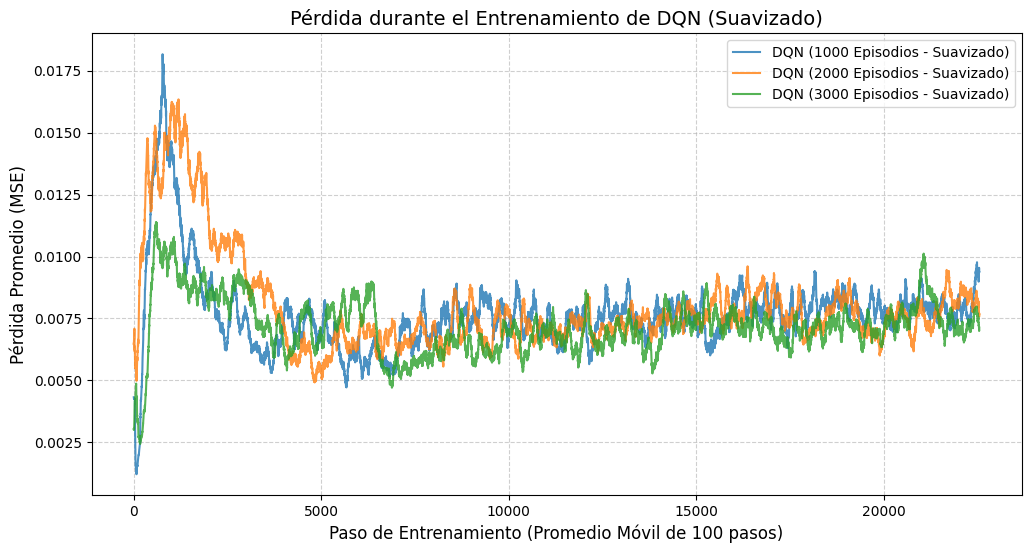

In [32]:
# prompt:  Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con  promedio móvil para cada uno de los agentes: agente_dqn, agente_dqn_2 y agente dqn_3

# Calcular promedio móvil de la pérdida para cada agente
window_loss = 100

losses_dqn_suavizado = moving_average(agente_dqn.losses, window_loss)
losses_dqn_2_suavizado = moving_average(agente_dqn_2.losses, window_loss)
losses_dqn_3_suavizado = moving_average(agente_dqn_3.losses, window_loss)

# Ajustar la longitud mínima para las series suavizadas de pérdida
min_len_loss_suavizado = min(len(losses_dqn_suavizado), len(losses_dqn_2_suavizado), len(losses_dqn_3_suavizado))

# Graficar las pérdidas suavizadas de los tres agentes DQN
plt.figure(figsize=(12, 6))
plt.plot(losses_dqn_suavizado[:min_len_loss_suavizado], label=f'DQN (1000 Episodios - Suavizado)', alpha=0.8)
plt.plot(losses_dqn_2_suavizado[:min_len_loss_suavizado], label=f'DQN (2000 Episodios - Suavizado)', alpha=0.8)
plt.plot(losses_dqn_3_suavizado[:min_len_loss_suavizado], label=f'DQN (3000 Episodios - Suavizado)', alpha=0.8)

plt.xlabel(f'Paso de Entrenamiento (Promedio Móvil de {window_loss} pasos)', fontsize=12)
plt.ylabel('Pérdida Promedio (MSE)', fontsize=12)
plt.title('Pérdida durante el Entrenamiento de DQN (Suavizado)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## **CONCLUSIONES SURGIDAS DEL PUNTO A**

---

--TASA DE EXITO--

---
1.  **Política Aleatoria**:

La política aleatoria mantiene una tasa de éxito muy baja y prácticamente constante entre los distintos entrenamientos (0.012 con 1000 episodios, 0.015 con 2000, y 0.014 con 3000). Esto se debe a que este agente no incorpora aprendizaje alguno y toma decisiones completamente al azar. Su rendimiento sirve solo como una base para comparar el desempeño de agentes que sí aprenden, pero su falta de adaptación al entorno impide mejoras, incluso con mayor cantidad de episodios.

2.  **Q-Learning Tabular**:

El agente Q-Learning Tabular, en el contexto que lo evalué (con la semilla de reproducción que utilicé, ya que cambian los valores con el cambio de semilla) muestra una evolución dispar frente al aumento de episodios.

Inicialmente, al pasar de 1000 a 2000 episodios, mejora su tasa de éxito de 0.404 a 0.510, lo que indica que, levemente, pero está aprendiendo una política más efectiva a medida que explora y actualiza su tabla Q. Sin embargo, al alcanzar los 3000 episodios, su rendimiento cae drásticamente a 0.153. Esta regresión sugiere problemas como una exploración insuficiente (debido a un epsilon que decayó demasiado rápido), sobreajuste a trayectorias menos óptimos o inestabilidad en entornos estocásticos (aleotoriedad o incertidumbre) como FrozenLake. Esto revela que, sin un control cuidadoso de los hiperparámetros, más entrenamiento puede perjudicar el desempeño.

3. **Deep Q-Network (DQN)**:

El agente basado en redes neuronales, DQN, presenta el comportamiento más sólido y consistente frente al aumento de episodios. Su tasa de éxito crece de 0.607 con 1000 episodios a 0.726 con 2000, y se mantiene relativamente estable con 0.693 al llegar a los 3000 episodios. Esta ligera disminución final es mínima y no indica un deterioro real del aprendizaje. El DQN aprovecha su capacidad de generalización para construir políticas más robustas, lo que hace que no le afecte tanto alguna exploración inicial deficiente o la variabilidad del entorno. En conjunto, demuestra una mayor adaptabilidad y estabilidad que los métodos tabulares.



---

--GRAFICA DE EVOLUCION DE LAS RECOMPENSAS--



---
Tomando para comaparar el entrenamiento con 1000 y 2000 episodios:

📈 Entrenamiento con 1000 episodios:

- Política Aleatoria : Se mantiene constantemente con recompensas cercanas a cero, lo cual es esperable ya que no aprende ni mejora.

- Q-Learning : Muestra una progresión gradual. Alrededor del episodio 600 comienza a estabilizarse en recompensas promedio cercanas a 0.4–0.45, indicando que ha aprendido una política parcialmente eficaz.

- DQN : Aprende más rápidamente que Q-Learning, con un aumento pronunciado desde el episodio 200. Al final del entrenamiento alcanza recompensas promedio superiores a 0.5, mostrando mejor rendimiento general que Q-Learning.

📈 Entrenamiento con 2000 episodios:

- Política Aleatoria: Sigue con recompensas cercanas a cero, sin variaciones notables.

- Q-Learning: Mejora respecto al entrenamiento anterior. Alcanza recompensas promedio de aproximadamente 0.6, aunque con más fluctuaciones y caídas puntuales (variabilidad estocástica) que coincide con lo que se veía en la tasa de exito a medida que aumentaban los episodios en este contexto.

- DQN: Continúa mostrando un mejor desempeño. Aumenta rápidamente desde los primeros episodios y mantiene una recompensa promedio mayor que 0.6 en muchos tramos, superando a Q-Learning en estabilidad y nivel de recompensa.



---
EVOLUCION DE LA PERDIDA DEL AGENTE DQN

---
- Comportamiento general:

En las primeras etapas del entrenamiento, la pérdida aumenta rápidamente hasta un pico, lo que indica que los modelos están ajustando sus predicciones iniciales.

Luego la pérdida disminuye rápidamente, mostrando que los agentes están aprendiendo a predecir mejor el valor esperado.

A partir de un cierto punto (~paso 5000 en adelante), la pérdida se estabiliza alrededor de valores bajos (aprox. 0.005 a 0.01) y oscila ligeramente.

- Comparación entre los distintos entrenamientos:

El agente con 3000 episodios comienza con una pérdida inicial menor y alcanza valores más bajos de pérdida promedio que los otros dos agentes, indicando un aprendizaje más efectivo.

El que entrené con 2000 episodios muestra un pico de pérdida más alto y tarda un poco más en estabilizarse, pero luego converge a un nivel de pérdida similar al del agente con 3000 episodios.

Lo que se observa con el de 1000 episodios de entrenamiento es que tiene un comportamiento intermedio, pero en la fase final tiene una pérdida promedio algo más alta y más fluctuaciones.



A medida que se incrementa la cantidad de episodios de entrenamiento, la pérdida promedio tiende a ser más baja y más estable, lo que indica un mejor aprendizaje del agente DQN; aunque la diferencia entre 2000 y 3000 episodios no es tan grande, sugiriendo que después de cierto punto el beneficio de seguir entrenando disminuye (retornos decrecientes).

Esto refleja un compromiso entre tiempo de entrenamiento y mejora del modelo.




## B) Considere modificar el modelo DQN el hiperparámetro gamma: un valor bajo, uno medio y uno alto. Entrene los tres modelos y compare los resultados. Comparta sus conclusiones

🔬 COMPARACIÓN DE DQN CON DIFERENTES VALORES DE GAMMA

--- Entrenando DQN con gamma = 0.3 ---
🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.010, Epsilon = 0.367, Loss = 0.0013
Episodio 400: Tasa éxito = 0.040, Epsilon = 0.135, Loss = 0.0013
Episodio 600: Tasa éxito = 0.040, Epsilon = 0.049, Loss = 0.0014
Episodio 800: Tasa éxito = 0.050, Epsilon = 0.018, Loss = 0.0026
Episodio 1000: Tasa éxito = 0.040, Epsilon = 0.010, Loss = 0.0025

✅ Entrenamiento Deep Q-Network (DQN) completado!
📊 Evaluando Deep Q-Network (DQN)...
Tasa de éxito: 0.052
Pasos promedio: 5.2

--- Entrenando DQN con gamma = 0.65 ---
🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.030, Epsilon = 0.367, Loss = 0.0016
Episodio 400: Tasa éxito = 0.050, Epsilon = 0.135, Loss = 0.0026
Episodio 600: Tasa éxito = 0.100, Epsilon = 0.049, Loss = 0.0032
Episodio 800: Tasa éxito = 0.130, Epsilon = 0.018, Loss = 0.0043
Episodio 1000: Tasa éxito

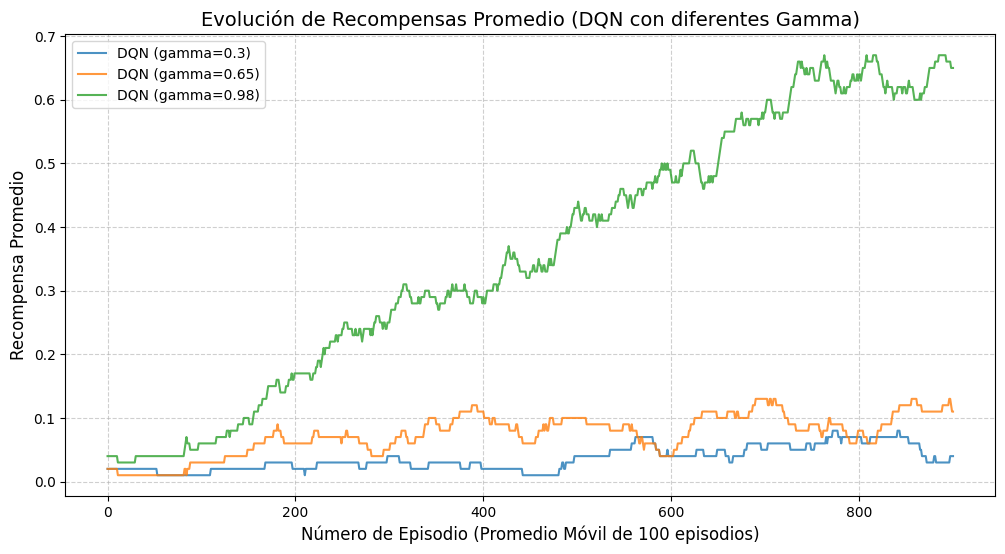

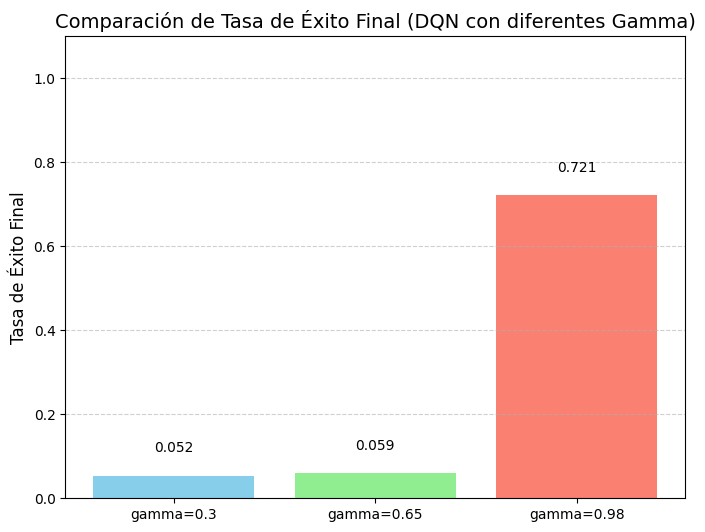


🗺️ Tasa de Exito para diferentes Gammas:
Gamma 0.3: Tasa de éxito = 0.052
Gamma 0.65: Tasa de éxito = 0.059
Gamma 0.98: Tasa de éxito = 0.721

🗺️ Políticas aprendidas para diferentes Gammas:


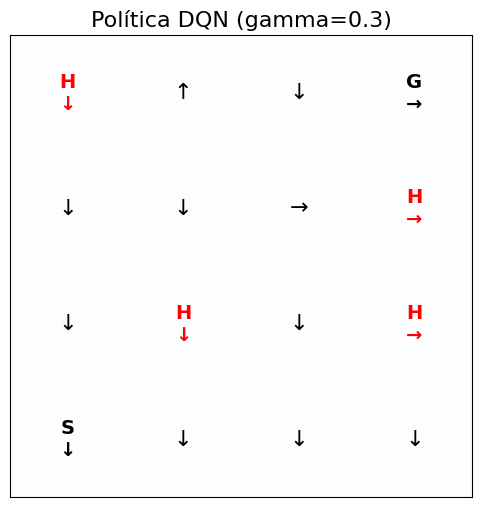

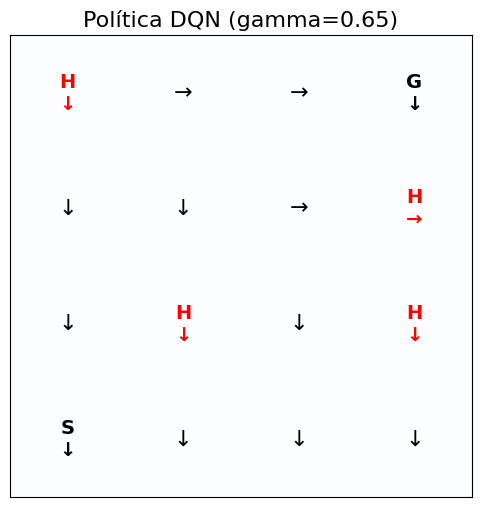

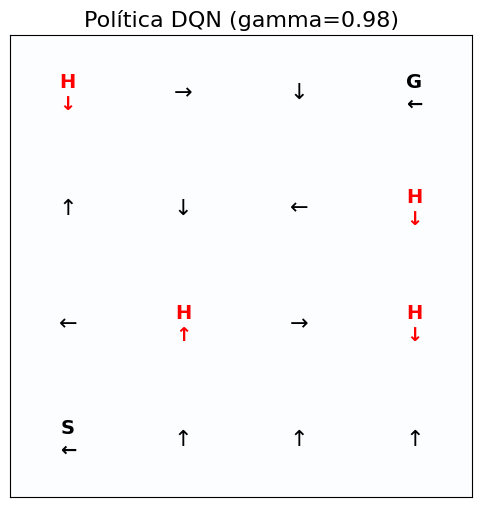

In [33]:
# prompt: necesito comparar los modelos q-learnig-tabular y deep q-network, modificando en el entrenamiento el factor gamma (tomando un valor bajo=0.30, un valor medio=0.65 y un valor alto=0.98). Luego debo evaluar los modelos y graficar la evolución del valor de las recompensas promedio movil en función de los episodios y por otro lado  un grafico de barras de la tasa de éxito final.

# Definir los valores de gamma a probar
gammas = [0.30, 0.65, 0.98]
resultados_gamma_dqn = {}
episodios_entrenamiento = 1000 # Número de episodios para cada entrenamiento

print("🔬 COMPARACIÓN DE DQN CON DIFERENTES VALORES DE GAMMA")
print("=" * 50)

for gamma_val in gammas:
    print(f"\n--- Entrenando DQN con gamma = {gamma_val} ---")
    set_seed(env=env) # Asegurar reproducibilidad para cada run de gamma

    # Crear y entrenar agente DQN con el gamma actual
    agente_dqn_gamma = DQNAgent(env.observation_space.n, env.action_space.n,
                                lr=0.001, gamma=gamma_val, epsilon=1.0)
    recompensas_dqn_gamma = agente_dqn_gamma.entrenar(env, episodios=episodios_entrenamiento)

    # Evaluar agente DQN entrenado
    tasa_exito_gamma, _ = agente_dqn_gamma.evaluar(env, episodios=1000) # Evaluar siempre con 1000 episodios

    # Guardar resultados
    resultados_gamma_dqn[gamma_val] = {
        'recompensas': recompensas_dqn_gamma,
        'tasa_exito': tasa_exito_gamma,
        'agente': agente_dqn_gamma # Guardamos el agente para inspección si es necesario
    }

print("\n✅ Entrenamiento y Evaluación con diferentes Gammas completado!")

# --- Visualización de resultados ---

# 1. Gráfica de Evolución de Recompensas Promedio Móvil
plt.figure(figsize=(12, 6))
window = 100 # Tamaño de la ventana para el promedio móvil

for gamma_val, resultados in resultados_gamma_dqn.items():
    recompensas_suavizadas = moving_average(resultados['recompensas'], window)
    plt.plot(recompensas_suavizadas, label=f'DQN (gamma={gamma_val})', alpha=0.8)

plt.xlabel(f'Número de Episodio (Promedio Móvil de {window} episodios)', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title('Evolución de Recompensas Promedio (DQN con diferentes Gamma)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Gráfica de Barras de Tasa de Éxito Final
gammas_labels = [f'gamma={g}' for g in gammas]
tasas_exito_gammas = [resultados_gamma_dqn[g]['tasa_exito'] for g in gammas]

plt.figure(figsize=(8, 6))
barras = plt.bar(gammas_labels, tasas_exito_gammas, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Tasa de Éxito Final', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final (DQN con diferentes Gamma)', fontsize=14)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización

# Añadir los valores de las tasas de éxito encima de cada barra
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3. Comparación de Políticas aprendidas para cada gamma
print("\n🗺️ Políticas aprendidas para diferentes Gammas:")
for gamma_val, resultados in resultados_gamma_dqn.items():
    politica = resultados['agente'].obtener_politica()
    visualizar_politica(politica, f"Política DQN (gamma={gamma_val})")



In [35]:
# prompt:  En base a los resultados anteriores imprime un resumen comparando para el agente DQN entrenado con cada valor de gamma, la tasa de exito obtenida, el numero de pasos promedio y la recompensa promedio

# Imprimir resumen comparando los resultados para cada valor de gamma
print("\n📊 RESUMEN COMPARATIVO DQN con diferentes Gammas")
print("=" * 60)
print(f"{'Gamma':<10} | {'Tasa de Éxito Promedio':<25} | {'Pasos Promedio':<18} | {'Recompensa Promedio por Episodio (Evaluación)':<45}")
print("-" * 60)

for gamma_val, resultados in resultados_gamma_dqn.items():
    # Recuperar el agente entrenado
    agente = resultados['agente']


    # Mejorar la evaluación para capturar los pasos promedio
    def evaluar_con_pasos(agente, env, episodios=100):
        exitos = 0
        recompensas = []
        pasos_totales = []

        for _ in range(episodios):
            estado, _ = env.reset()
            recompensa_total = 0
            terminado = False
            pasos = 0

            while not terminado and pasos < 100:
                accion = agente.seleccionar_accion(estado, entrenando=False)
                estado, recompensa, terminado, truncated, _ = env.step(accion)

                if truncated:
                    terminado = True

                recompensa_total += recompensa
                pasos += 1

            if recompensa_total > 0:
                exitos += 1
            recompensas.append(recompensa_total)
            pasos_totales.append(pasos)

        tasa_exito = exitos / episodios
        pasos_promedio = np.mean(pasos_totales)
        recompensa_promedio = np.mean(recompensas)

        return tasa_exito, recompensa_promedio, pasos_promedio

    # Volver a evaluar para obtener pasos promedio y recompensa promedio
    _, recompensa_eval_promedio, pasos_eval_promedio = evaluar_con_pasos(agente, env, episodios=100) # Usar 100 episodios para evaluación

    print(f"{gamma_val:<10.2f} | {resultados['tasa_exito']:<25.3f} | {pasos_eval_promedio:<18.1f} | {recompensa_eval_promedio:<45.3f}")

print("-" * 120)



📊 RESUMEN COMPARATIVO DQN con diferentes Gammas
Gamma      | Tasa de Éxito Promedio    | Pasos Promedio     | Recompensa Promedio por Episodio (Evaluación)
------------------------------------------------------------
0.30       | 0.052                     | 5.5                | 0.050                                        
0.65       | 0.059                     | 5.6                | 0.030                                        
0.98       | 0.721                     | 46.9               | 0.800                                        
------------------------------------------------------------


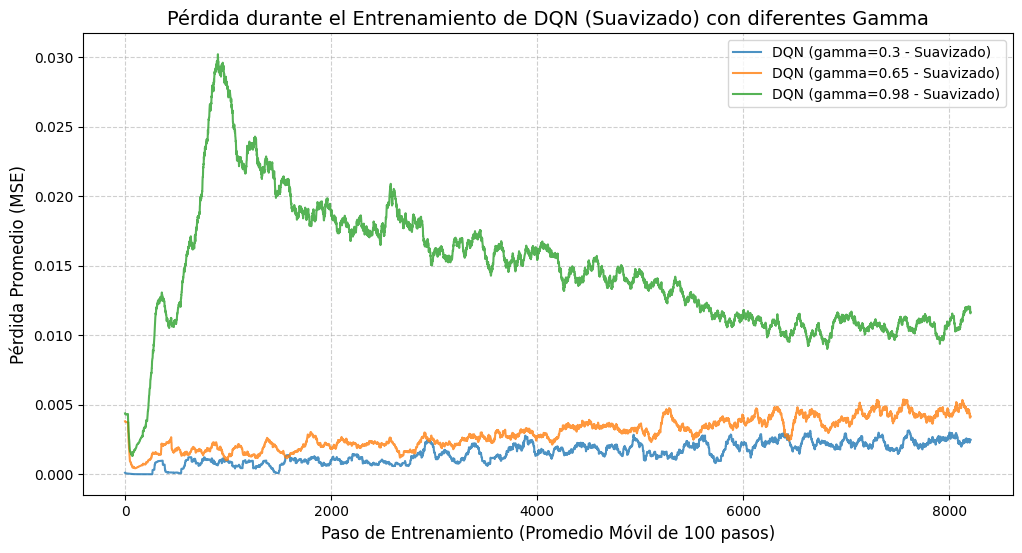

In [36]:
# prompt:  Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con  promedio móvil para cada uno de los agentes entrenados con los diferentes valores de gamma

# Calcular promedio móvil de la pérdida para cada agente
window_loss = 100

# Obtener las pérdidas de cada agente entrenado con diferentes gammas
losses_gamma_030 = resultados_gamma_dqn[0.30]['agente'].losses
losses_gamma_065 = resultados_gamma_dqn[0.65]['agente'].losses
losses_gamma_098 = resultados_gamma_dqn[0.98]['agente'].losses

losses_gamma_030_suavizado = moving_average(losses_gamma_030, window_loss)
losses_gamma_065_suavizado = moving_average(losses_gamma_065, window_loss)
losses_gamma_098_suavizado = moving_average(losses_gamma_098, window_loss)

# Ajustar la longitud mínima para las series suavizadas de pérdida
min_len_loss_suavizado = min(len(losses_gamma_030_suavizado), len(losses_gamma_065_suavizado), len(losses_gamma_098_suavizado))

# Graficar las pérdidas suavizadas de los tres agentes DQN
plt.figure(figsize=(12, 6))
plt.plot(losses_gamma_030_suavizado[:min_len_loss_suavizado], label=f'DQN (gamma={gammas[0]} - Suavizado)', alpha=0.8)
plt.plot(losses_gamma_065_suavizado[:min_len_loss_suavizado], label=f'DQN (gamma={gammas[1]} - Suavizado)', alpha=0.8)
plt.plot(losses_gamma_098_suavizado[:min_len_loss_suavizado], label=f'DQN (gamma={gammas[2]} - Suavizado)', alpha=0.8)

plt.xlabel(f'Paso de Entrenamiento (Promedio Móvil de {window_loss} pasos)', fontsize=12)
plt.ylabel('Pérdida Promedio (MSE)', fontsize=12)
plt.title('Pérdida durante el Entrenamiento de DQN (Suavizado) con diferentes Gamma', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## **CONCLUSIONES SURGIDAS DEL PUNTO B**

--- Conclusiones sobre el efecto de Gamma en DQN ---
Gamma es el factor de descuento, que determina la importancia de las recompensas futuras.

**TASA DE EXITO - PASOS PROMEDIO Y RECOMPENSAS:**
- Un gamma BAJO (ej: 0.30):

Hace que el agente no "vea" mas que en la cercanía, priorizando las recompensas inmediatas.
Con este valor el agente DQN muestra un comportamiento  cortoplacista, priorizando las recompensas inmediatas y casi ignorando el valor de las decisiones futuras. Esto se refleja en su muy baja tasa de éxito (5.2 %) y recompensas promedio insignificantes (0.050). Tiene un número de pasos promedio por episodio bajo (5.5), esto no se traduce en un aprendizaje eficaz, ya que el agente no logra desarrollar una política coherente que le permita alcanzar la meta. Este nivel de descuento limita fuertemente la capacidad del agente para planificar y resolver entornos que requieren exploración cuidadosa y toma de decisiones en base a consecuencias futuras.

- Un gamma MEDIO (ej: 0.65):

Hace que el agente sea previsor y valore mucho las recompensas futuras.
Al aumentar gamma a 0.65, el agente mejora levemente en cuanto a la consideración del futuro, pero aún permanece enfocado en recompensas a corto plazo. La tasa de éxito apenas sube al 5.9 % y la recompensa promedio incluso desciende a 0.030, lo que sugiere que el agente está explorando más sin obtener beneficios claros. La media de pasos por episodio se mantiene casi igual (5.6), es decir que la estrategia no es muy distinta. Este valor intermedio de gamma sigue siendo insuficiente para que el agente aprenda políticas efectivas en entornos con caminos largos y consecuencias con algún retardo.



- Un gamma ALTO (ej: 0.98):

Aquí el agente alcanza un desempeño realmente mejor, logrando una tasa de éxito del 72.1 % y una recompensa promedio de 0.800 por episodio. Este comportamiento indica que el agente ha aprendido a planificar a largo plazo, evaluando correctamente las secuencias de acciones que lo llevan hacia la meta, aunque esto implique tomar trayectorias más largas (46.9 pasos en promedio).
Este nivel de descuento permite que el agente aproveche la estructura del entorno y tome decisiones informadas basadas en los beneficios futuros, esto es lo que lleva a una política más exitosa y consistente.

Observando las gráficas:
- La gráfica de recompensas promedio móvil muestra cómo los agentes con gammas más altos
  (en este entorno) alcanzan un rendimiento superior y más estable a medida que avanza el entrenamiento.
- La gráfica de barras de tasa de éxito final confirma que los gammas más altos
  conducen a una mayor probabilidad de alcanzar el objetivo en la evaluación.
- La visualización de las políticas aprendidas muestra como el agente con gammas bajos se 'pierde' o se queda atascado en lugares no óptimos.


**EVOLUCION DE LA PERDIDA PROMEDIO MOVIL:**

 - Gamma = 0.3:

El agente con gamma 0.3 muestra una pérdida promedio consistentemente baja y estable a lo largo del entrenamiento. Esto indica que el modelo logra predecir con precisión los valores Q cuando se enfoca en recompensas inmediatas. Sin embargo, al tener una visión muy cortoplacista del entorno, es probable que su desempeño general en términos de toma de decisiones óptimas a largo plazo sea limitado. Este valor de gamma favorece la estabilidad, pero a costa de una política menos estratégica.

- Gamma = 0.65:

El entrenamiento con gamma 0.65 presenta un comportamiento intermedio, con una pérdida promedio mayor que la de gamma 0.3 y con ligeras oscilaciones. Esto sugiere que el agente intenta equilibrar la valoración de recompensas a corto y mediano plazo, pero sin lograr aún una estimación completamente precisa de los valores Q. Aunque el aprendizaje es más desafiante que con gamma bajo, este valor podría representar un compromiso razonable entre estabilidad y estrategia, dependiendo del entorno.

- Gamma = 0.98:

El agente con gamma 0.98 muestra una pérdida promedio  más alta y más inestable a lo largo del entrenamiento. Esta dificultad para minimizar la pérdida se debe a la complejidad que implica valorar las recompensas a largo plazo, lo que genera errores mayores en las predicciones Q. Este enfoque conduce a una política más óptima en este contexto.

## C) Lo mismo que en B) pero para el hiperparámetro alpha.

🔬 COMPARACIÓN DE DQN CON DIFERENTES VALORES DE ALPHA (Tasa de Aprendizaje)

--- Entrenando DQN con alpha = 0.0001 ---
🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.100, Epsilon = 0.367, Loss = 0.0049
Episodio 400: Tasa éxito = 0.090, Epsilon = 0.135, Loss = 0.0066
Episodio 600: Tasa éxito = 0.310, Epsilon = 0.049, Loss = 0.0067
Episodio 800: Tasa éxito = 0.500, Epsilon = 0.018, Loss = 0.0084
Episodio 1000: Tasa éxito = 0.580, Epsilon = 0.010, Loss = 0.0087

✅ Entrenamiento Deep Q-Network (DQN) completado!
📊 Evaluando Deep Q-Network (DQN)...
Tasa de éxito: 0.497
Pasos promedio: 31.1

--- Entrenando DQN con alpha = 0.001 ---
🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.060, Epsilon = 0.367, Loss = 0.0093
Episodio 400: Tasa éxito = 0.160, Epsilon = 0.135, Loss = 0.0076
Episodio 600: Tasa éxito = 0.320, Epsilon = 0.049, Loss = 0.0081
Episodio 800: Tasa éxito = 0.410, Epsilon = 0.018, Loss = 0.007

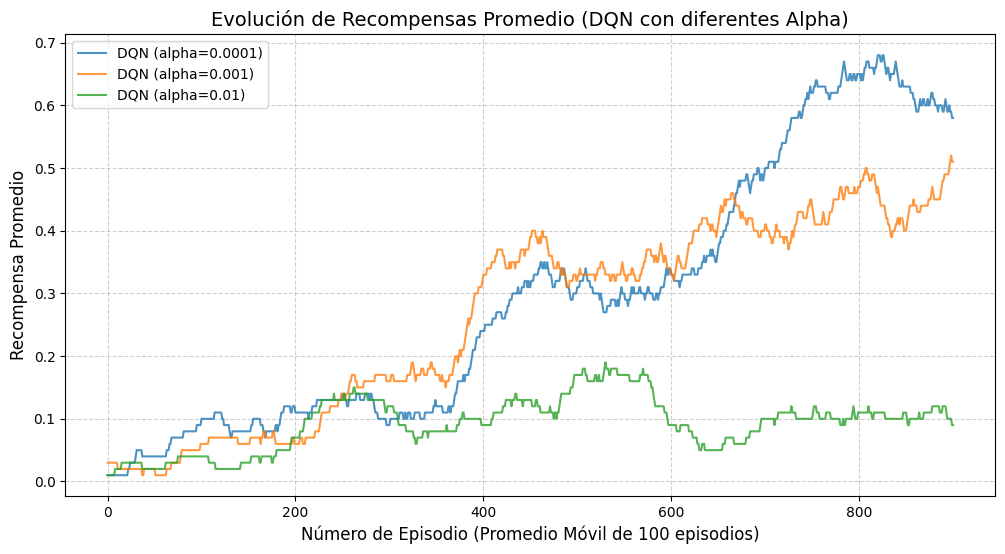

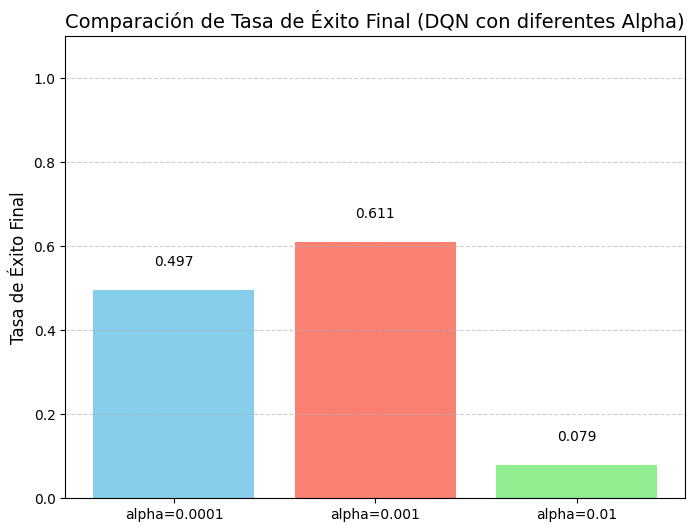

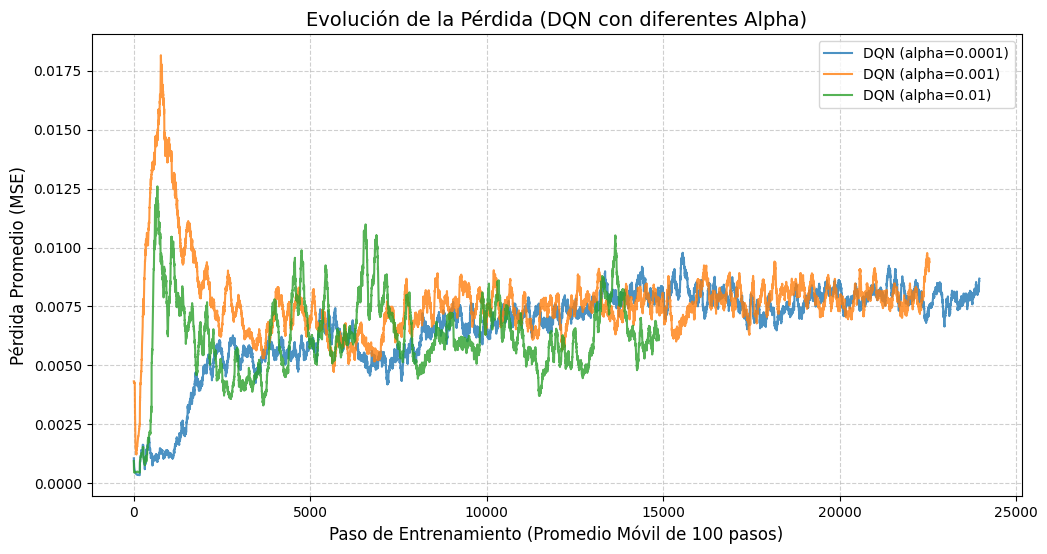


🗺️ Políticas aprendidas para diferentes Alphas:


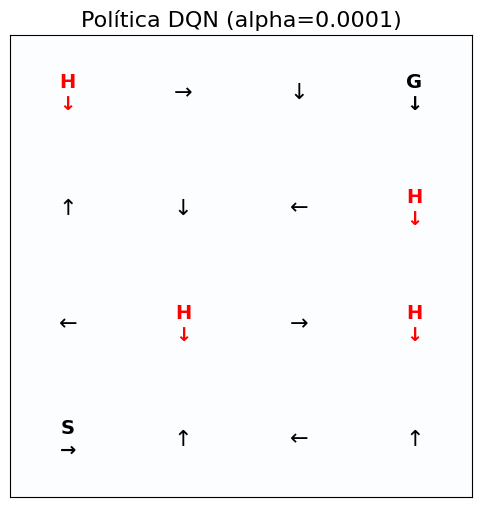

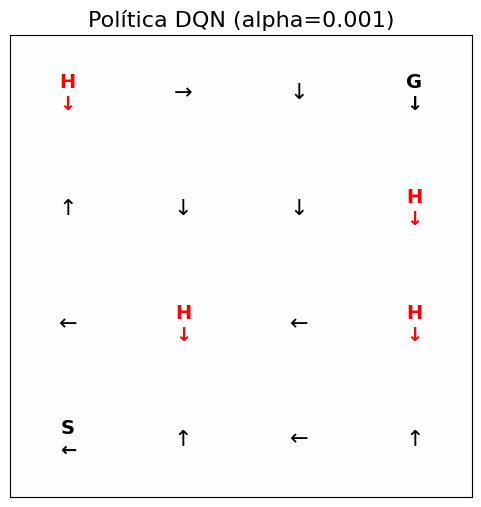

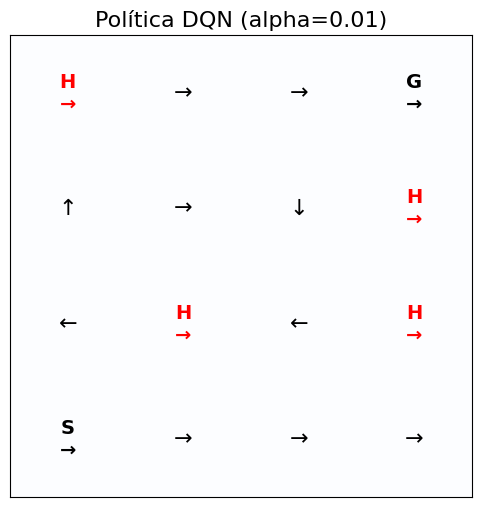

In [37]:
# prompt: Crea un codigo similar pero que modifique el parametro alpha, manteniendo constante los demas parametros del modelo. Grafica los resultados de la comparacion de tasa de éxito final, evolucion de las recompensas y pérdida, y visualizacion de la politica aprendida.

# C) Considere modificar el modelo DQN el hiperparámetro alpha (tasa de aprendizaje): un valor bajo, uno medio y uno alto. Entrene los tres modelos y compare los resultados. Comparta sus conclusiones
set_seed(env=env)
# Definir los valores de alpha (tasa de aprendizaje) a probar
alphas = [0.0001, 0.001, 0.01]
resultados_alpha_dqn = {}
episodios_entrenamiento = 1000 # Número de episodios para cada entrenamiento
gamma_fijo = 0.95 # Mantener gamma constante

print("🔬 COMPARACIÓN DE DQN CON DIFERENTES VALORES DE ALPHA (Tasa de Aprendizaje)")
print("=" * 60)

for alpha_val in alphas:
    print(f"\n--- Entrenando DQN con alpha = {alpha_val} ---")
    set_seed(env=env) # Asegurar reproducibilidad para cada run de alpha

    # Crear y entrenar agente DQN con el alpha actual
    agente_dqn_alpha = DQNAgent(env.observation_space.n, env.action_space.n,
                                lr=alpha_val, gamma=gamma_fijo, epsilon=1.0)
    recompensas_dqn_alpha = agente_dqn_alpha.entrenar(env, episodios=episodios_entrenamiento)

    # Evaluar agente DQN entrenado
    tasa_exito_alpha, _ = agente_dqn_alpha.evaluar(env, episodios=1000) # Evaluar siempre con 1000 episodios

    # Guardar resultados
    resultados_alpha_dqn[alpha_val] = {
        'recompensas': recompensas_dqn_alpha,
        'tasa_exito': tasa_exito_alpha,
        'agente': agente_dqn_alpha, # Guardamos el agente para inspección si es necesario
        'losses': agente_dqn_alpha.losses # Guardamos las pérdidas para analizar el alpha
    }

print("\n✅ Entrenamiento y Evaluación con diferentes Alphas completado!")

# --- Visualización de resultados ---

# 1. Gráfica de Evolución de Recompensas Promedio Móvil
plt.figure(figsize=(12, 6))
window = 100 # Tamaño de la ventana para el promedio móvil

for alpha_val, resultados in resultados_alpha_dqn.items():
    recompensas_suavizadas = moving_average(resultados['recompensas'], window)
    plt.plot(recompensas_suavizadas, label=f'DQN (alpha={alpha_val})', alpha=0.8)

plt.xlabel(f'Número de Episodio (Promedio Móvil de {window} episodios)', fontsize=12)
plt.ylabel('Recompensa Promedio', fontsize=12)
plt.title('Evolución de Recompensas Promedio (DQN con diferentes Alpha)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Gráfica de Barras de Tasa de Éxito Final
alphas_labels = [f'alpha={a}' for a in alphas]
tasas_exito_alphas = [resultados_alpha_dqn[a]['tasa_exito'] for a in alphas]

plt.figure(figsize=(8, 6))
barras = plt.bar(alphas_labels, tasas_exito_alphas, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Tasa de Éxito Final', fontsize=12)
plt.title('Comparación de Tasa de Éxito Final (DQN con diferentes Alpha)', fontsize=14)
plt.ylim(0, 1.1) # Limitar el eje Y de 0 a 1.1 para mejor visualización

# Añadir los valores de las tasas de éxito encima de cada barra
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3. Gráfica de Evolución de la Pérdida (Promedio Móvil)
plt.figure(figsize=(12, 6))
window_loss = 100 # Tamaño de la ventana para el promedio móvil de la pérdida

for alpha_val, resultados in resultados_alpha_dqn.items():
    losses_suavizadas = moving_average(resultados['losses'], window_loss)
    plt.plot(losses_suavizadas, label=f'DQN (alpha={alpha_val})', alpha=0.8)

plt.xlabel(f'Paso de Entrenamiento (Promedio Móvil de {window_loss} pasos)', fontsize=12)
plt.ylabel('Pérdida Promedio (MSE)', fontsize=12)
plt.title('Evolución de la Pérdida (DQN con diferentes Alpha)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 4. Opcional: Comparación de Políticas aprendidas para cada alpha
print("\n🗺️ Políticas aprendidas para diferentes Alphas:")
for alpha_val, resultados in resultados_alpha_dqn.items():
    politica = resultados['agente'].obtener_politica()
    visualizar_politica(politica, f"Política DQN (alpha={alpha_val})")




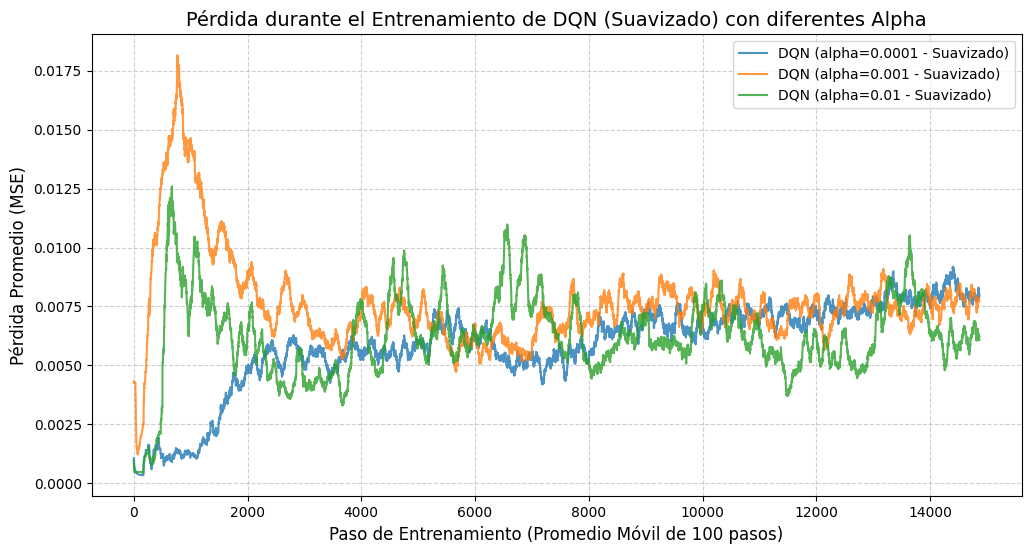

In [ ]:


# Calcular promedio móvil de la pérdida para cada agente entrenado con diferentes alphas
window_loss = 100

# Obtener las pérdidas de cada agente
losses_alpha_0001 = resultados_alpha_dqn[0.0001]['losses']
losses_alpha_001 = resultados_alpha_dqn[0.001]['losses']
losses_alpha_01 = resultados_alpha_dqn[0.01]['losses']

# Calcular los promedios móviles
losses_alpha_0001_suavizado = moving_average(losses_alpha_0001, window_loss)
losses_alpha_001_suavizado = moving_average(losses_alpha_001, window_loss)
losses_alpha_01_suavizado = moving_average(losses_alpha_01, window_loss)

# Ajustar la longitud mínima para las series suavizadas de pérdida
min_len_loss_suavizado = min(len(losses_alpha_0001_suavizado), len(losses_alpha_001_suavizado), len(losses_alpha_01_suavizado))

# Graficar las pérdidas suavizadas de los tres agentes DQN
plt.figure(figsize=(12, 6))
plt.plot(losses_alpha_0001_suavizado[:min_len_loss_suavizado], label=f'DQN (alpha={alphas[0]} - Suavizado)', alpha=0.8)
plt.plot(losses_alpha_001_suavizado[:min_len_loss_suavizado], label=f'DQN (alpha={alphas[1]} - Suavizado)', alpha=0.8)
plt.plot(losses_alpha_01_suavizado[:min_len_loss_suavizado], label=f'DQN (alpha={alphas[2]} - Suavizado)', alpha=0.8)

plt.xlabel(f'Paso de Entrenamiento (Promedio Móvil de {window_loss} pasos)', fontsize=12)
plt.ylabel('Pérdida Promedio (MSE)', fontsize=12)
plt.title('Pérdida durante el Entrenamiento de DQN (Suavizado) con diferentes Alpha', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


In [38]:
# prompt:  En base a los resultados anteriores imprime un resumen comparando para el agente DQN entrenado con cada valor de alpha, la tasa de exito obtenida, el numero de pasos promedio y la recompensa promedio

# Imprimir resumen comparando los resultados para cada valor de alpha
print("\n📊 RESUMEN COMPARATIVO DQN con diferentes Alphas")
print("=" * 60)
print(f"{'Alpha':<10} | {'Tasa de Éxito Promedio':<25} | {'Pasos Promedio':<18} | {'Recompensa Promedio por Episodio (Evaluación)':<45}")
print("-" * 60)

for alpha_val, resultados in resultados_alpha_dqn.items():
    # Recuperar el agente entrenado
    agente = resultados['agente']

    # Volver a evaluar para obtener pasos promedio y recompensa promedio
    _, recompensa_eval_promedio, pasos_eval_promedio = evaluar_con_pasos(agente, env, episodios=100) # Usar 100 episodios para evaluación

    print(f"{alpha_val:<10.4f} | {resultados['tasa_exito']:<25.3f} | {pasos_eval_promedio:<18.1f} | {recompensa_eval_promedio:<45.3f}")

print("-" * 120)




📊 RESUMEN COMPARATIVO DQN con diferentes Alphas
Alpha      | Tasa de Éxito Promedio    | Pasos Promedio     | Recompensa Promedio por Episodio (Evaluación)
------------------------------------------------------------
0.0001     | 0.497                     | 33.2               | 0.490                                        
0.0010     | 0.611                     | 34.4               | 0.720                                        
0.0100     | 0.079                     | 8.9                | 0.110                                        
------------------------------------------------------------------------------------------------------------------------


--- Conclusiones sobre el efecto de Alpha (Tasa de Aprendizaje) en DQN ---
Alpha (o Learning Rate) controla qué tan rápido la red neuronal ajusta sus pesos
basándose en el error (la diferencia entre el Q-valor predicho y el objetivo).

**TASA DE EXITO - PASOS PROMEDIO Y RECOMPENSAS:**
- **Alpha = 0.0001**:

Con una tasa de aprendizaje muy baja, el agente aprende lentamente pero de forma estable. La tasa de éxito promedio (0.497) indica que logra completar casi la mitad de los episodios con éxito, lo que es razonable considerando el entorno variable. Sin embargo, la recompensa promedio es moderada (0.490) y los pasos promedio son altos (33.2), lo que sugiere que el agente aún no ha optimizado del todo su política y requiere más tiempo de entrenamiento para mejorar su rendimiento.

- **Alpha = 0.0010**:

Este valor de alpha representa el mejor equilibrio observado en el experimento. El agente alcanza la tasa de éxito más alta (0.611) y una recompensa promedio mayor (0.720), lo que indica que ha aprendido una política mejor. Aunque los pasos promedio por episodio son altos (34.4), este alpha permite un aprendizaje suficientemente rápido sin sacrificar estabilidad.

- **Alpha = 0.0100**:

Una tasa de aprendizaje demasiado alta generó inestabilidad en el entrenamiento. El agente con alpha 0.01 tiene un desempeño muy pobre, con una tasa de éxito promedio baja de 0.079 y una recompensa promedio igual de baja baja (0.110). La cantidad reducida de pasos por episodio (8.9) sugiere que el agente frecuentemente cae en agujeros o termina el episodio de manera prematura por tomar decisiones sin haber "aprendido" lo suficiente.



- Observando las gráficas:

La gráfica de recompensas promedio móvil muestra cómo la velocidad y la estabilidad del aprendizaje varían con alpha. Para este entorno y número de episodios tanto el alpha bajo (0,0001) como el intermedio (0,001) muestran un curva creciente en las recompensas, al final termina con valores mas altos el alpha de 0,0001.

La gráfica de barras de tasa de éxito final demuestra que el mejor desempeño fue el del alpha intermedio.


**EVOLUCION DE LA PERDIDA PROMEDIO MOVIL:**:

- Alpha = 0.0001

El agente con esta tasa de aprendizaje tiene un ascenso lento de la pérdida en las primeras etapas, manteniéndose estable y baja a lo largo del tiempo. Esto demuestra un aprendizaje gradual y controlado, con menor oscilación, aunque  más lento para optener políticas óptimas.

- Alpha = 0.001

Inicialmente muestra un pico pronunciado de pérdida, lo que indica mayor inestabilidad al comienzo, pero luego desciende y se mantiene relativamente constante con lo que parece una pérdida promedio mayor que la de alpha=0.0001. Este valor dio un balance entre velocidad de aprendizaje y estabilidad.

- Alpha = 0.01

Con este valor se nota la mayor inestabilidad. Su pérdida sube rápidamente, alcanza valores altos y oscila mucho a lo largo del entrenamiento. Esto indica que el agente actualiza su política de manera demasiado agresiva, lo cual impide una convergencia clara y puede llevar a tomar decisiones muy variables.

**Referencias: **

---



---


- Prompts:
--  "como deberia modificar el codigo para crear una variable "episodios = x " y luego poder pasarle un parametro "episodios" a los agentes para que solo deba cambiarlo una vez en todo el codigo y se entrenen en base a el?"
-- "agrega el politica aleatoria tambien a la comparacion"
-- "Genera un gráfico de barras comparativo entre los 3 modelos, comparando la tasa de éxito final en los entrenamientos de 1000, 2000 y 3000 episodios. Para ello coloqué nombres diferentes a las variables de tasa de éxito final (finalizan en _1000, _2000 y _3000 respectivamente para identificarlas)"
-- "Compara los modelos q-learnig-tabular y deep q-network, modificando en el entrenamiento el factor gamma (tomando un valor bajo=0.30, un valor medio=0.65 y un valor alto=0.98). Luego debo evaluar los modelos y graficar la evolución del valor de las recompensas promedio movil en función de los episodios y por otro lado  un grafico de barras de la tasa de éxito final.
-- "Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con  promedio móvil para cada uno de los agentes: agente_dqn, agente_dqn_2 y agente dqn_3"
-- "Crea un codigo similar pero que modifique el parametro alpha, manteniendo constante los demas parametros del modelo. Grafica los resultados de la comparacion de tasa de éxito final, evolucion de las recompensas y pérdida, y visualizacion de la politica aprendida."
-- "En base a los resultados anteriores imprime un resumen comparando para el agente DQN entrenado con cada valor de alpha, la tasa de exito obtenida, el numero de pasos promedio y la recompensa promedio "
